[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Loicsav/SalasOrtegaConde/blob/main/k-brazos/Greedy.ipynb)

# **Estudio comparativo de algoritmos ε-greedy en un problema de k-armed bandit**

**Descripción**: El experimento compara el rendimiento de algoritmos ε-greedy en un problema de k-armed bandit. Se generan gráficas de recompensas promedio, de porcentaje de selección del brazo óptimo, de estadísticas de selección de cada brazo y de arrepentimiento acomulado promedio para cada algoritmo.

**Asignatura**: Extensiones de Machine Learning, 2025/2026

**Autores**: 
* Alberto Ortega Pastor
* Manuel Salas Díaz
* Lola Conde Herrera

**Máster de Inteligencia Artificial**

**Facultad de Informática**

-----

This software is licensed under the GNU General Public License v3.0 (GPL-3.0), with the additional restriction that it may not be used for commercial purposes.

For more details about GPL-3.0: https://www.gnu.org/licenses/gpl-3.0.html

----

## Preparación del entorno

Para la preparación del entorno, se clona el repositorio de GitHub con los archivos utilizados en el notebook.

In [ ]:
!git clone https://github.com/Loicsav/SalasOrtegaConde1.git
%cd SalasOrtegaConde1

Una vez clonado el repositorio, se instalan las dependencias necesarias para la ejecución del notebook.

In [ ]:
!pip install -r requirements.txt

Se importan las librerías necesarias.

In [1]:
import sys
import numpy as np
from typing import List
import numpy as np

from src.algorithms import Algorithm, EpsilonGreedy
from src.arms import ArmNormal, Bandit, ArmBernoulli, ArmBinomial
from src.plotting.plotting import plot_average_rewards, plot_optimal_selections, plot_arm_statistics, plot_regret, boxplot_estimaciones_brazos

A continuación, se utiliza una semilla para que el estudio sea reproducible. Además, se declaran las constantes del número de brazos, número de pasos, y número de ejecuciones para el estudio.

In [ ]:
seed = 42
np.random.seed(seed)

k = 10  # Número de brazos
steps = 1000  # Número de pasos que se ejecutarán cada algoritmo
runs = 500  # Número de ejecuciones

## **Experimentos**

Los algoritmos se ejecutan en el contexto de un problema del bandido de k-brazos, durante un número de pasos fijo. Se repite la ejecución un número fijo de veces.

En el estudio se utiliza un bandido de 10 brazos, ejecutado durante 1000 pasos, repetido un total de 500 ejecuciones. Se comparan los algoritmos con este procedimiento. En concreto, se realizan los siguientes experimentos:

* Valores de ε:
    - ε: $0$, el algoritmo sólo explota
    - ε: $0.01$, el algoritmo explora un 1% de las ocasiones y explora el 99%
    - ε: $0.1$, el algoritmo explora un 10% de las ocasiones y explora el 90%

* Experimentos:
    - Experimento 1: Distribución Normal
    - Experimento 2: Distribución Bernoulli
    - Experimento 3: Distribución Binomial

Para cada bandido, se comparan los algoritmos dada la recompensa promedio a lo largo del tiempo, el porcentaje de selección del brazo óptimo, y el porcentaje de selección y recompensas inferidas de cada brazo.

El siguiente código realiza un experimento con un bandido especificado, dada una lista de algoritmos, un número de pasos, y un número de ejecuciones. Devuelve una lista para cada algoritmo con la recompensa promedio de cada brazo y el número de veces que se ha seleccionado, valores que se obtienen de hacer la media de todas las ejecuciones. Además, se devuelve la recompensa obtenida en cada paso y el arrepentimiento, siendo estos los valores medios de todas las ejecuciones. Estos valores se utilizan para la realización de las gráficas usadas para la comparación de los algoritmos.

In [3]:
def run_experiment(bandit: Bandit, algorithms: List[Algorithm], steps: int, runs: int):

    # Recopilar estadísticas de brazos para cada algoritmo
    arm_stats = []
    for algo in algorithms:
        arm_data = [
            {
                'arm': i + 1,  # Número del brazo (1 al k)
                'counts': 0.0,  # Número de veces seleccionado
                'values': 0.0,  # Recompensa promedio estimada
            }
            for i in range(algo.k)
        ]
        arm_stats.append(arm_data)

    # Recopilar todas las estimaciones finales de cada algoritmo en cada ejecución
    all_runs_data = []
    for algo in algorithms:
        all_runs_data.append([])

    # Recopilar el número de ejecuciones de cada brazo para cada algoritmo en cada ejecución
    all_runs_counts = []
    for algo in algorithms:
        all_runs_counts.append([])

    optimal_arm = bandit.optimal_arm  # Necesario para calcular el porcentaje de selecciones óptimas.

    rewards = np.zeros((len(algorithms), steps)) # Matriz para almacenar las recompensas promedio.

    optimal_selections = np.zeros((len(algorithms), steps))  # Matriz para almacenar el porcentaje de selecciones óptimas.

    regrets = np.zeros((len(algorithms), steps))  # Matriz para almacenar el regret acumulado.

    for run in range(runs):
        current_bandit = Bandit(arms=bandit.arms)

        for algo in algorithms:
            algo.reset() # Reiniciar los valores de los algoritmos.

        total_rewards_per_algo = np.zeros(len(algorithms)) # Acumulador de recompensas por algoritmo. Necesario para calcular el promedio.

        for step in range(steps):
            for idx, algo in enumerate(algorithms):
                chosen_arm = algo.select_arm() # Seleccionar un brazo según la política del algoritmo.
                reward = current_bandit.pull_arm(chosen_arm) # Obtener la recompensa del brazo seleccionado.
                algo.update(chosen_arm, reward) # Actualizar el valor estimado del brazo seleccionado.

                rewards[idx, step] += reward # Acumular la recompensa obtenida en la matriz rewards para el algoritmo idx en el paso step.
                total_rewards_per_algo[idx] += reward # Acumular la recompensa obtenida en total_rewards_per_algo para el algoritmo idx.

                regrets[idx, step] += (current_bandit.get_expected_value(optimal_arm) - reward) # Acumular el regret obtenido en la matriz regrets para el algoritmo idx en el paso step.

                if chosen_arm == optimal_arm:
                    optimal_selections[idx, step] += 1
        for arms_algo, algo in zip(arm_stats, algorithms):
            for arm_data in arms_algo:
                i = arm_data["arm"] -1
                arm_data["counts"] = arm_data["counts"] + algo.counts[i]
                arm_data["values"] = arm_data["values"] + float(algo.values[i])
        for arm_values, algo in zip(all_runs_data, algorithms):
            lista = []
            for i in range(k):
                lista.append(algo.values[i])
            arm_values.append(lista)

        for arm_counts, algo in zip(all_runs_counts, algorithms):
            lista = []
            for i in range(k):
                lista.append(algo.counts[i])
            arm_counts.append(lista)


    rewards /= runs
    regrets /= runs
    optimal_selections /= runs
    
    # Recopilar estadísticas de brazos para cada algoritmo
    for arms_algo, algo in zip(arm_stats, algorithms):
            for arm_data in arms_algo:
                i = arm_data["arm"] -1
                arm_data["values"] = arm_data["values"]/runs
                arm_data["counts"] = arm_data["counts"]/runs

    return rewards, optimal_selections, arm_stats, regrets, all_runs_data, all_runs_counts

### **``1. Experimento distribución Normal``**

A continuación, se realiza el experimento con un bandido cuyas recompensas de cada brazo siguen una distribución normal con desviación estándar 1. Se comparan los algoritmos ε greedy con ε=0, ε=0.1, y ε=0.01.

In [4]:
# Creación del bandit
bandit = Bandit(arms=ArmNormal.generate_arms(k)) # Generar un bandido con k brazos de distribución normal
print(bandit)

optimal_arm = bandit.optimal_arm
print(f"Optimal arm: {optimal_arm + 1} with expected reward={bandit.get_expected_value(optimal_arm)}")

# Definir los algoritmos a comparar. En este caso son 3 algoritmos epsilon-greedy con diferentes valores de epsilon.
algorithms = [EpsilonGreedy(k=k, epsilon=0), EpsilonGreedy(k=k, epsilon=0.01), EpsilonGreedy(k=k, epsilon=0.1)]

# Ejecutar el experimento y obtener las recompensas promedio, porcentaje de selecciones óptimas y estadísticas de brazos
rewards, optimal_selections, arm_stats, regrets, all_runs_data, all_runs_counts = run_experiment(bandit, algorithms, steps, runs)

Bandit with 10 arms: ArmNormal(mu=1.52, sigma=1.0), ArmNormal(mu=2.4, sigma=1.0), ArmNormal(mu=1.19, sigma=1.0), ArmNormal(mu=4.37, sigma=1.0), ArmNormal(mu=6.39, sigma=1.0), ArmNormal(mu=7.59, sigma=1.0), ArmNormal(mu=8.8, sigma=1.0), ArmNormal(mu=9.56, sigma=1.0), ArmNormal(mu=6.41, sigma=1.0), ArmNormal(mu=7.37, sigma=1.0)
Optimal arm: 8 with expected reward=9.56


#### **Visualización**

En esta apartado vamos a mostrar y analizar las diferentes gráficas generadas para el experimento del bandido de k-brazos con distribución normal. Las gráficas que se van mostrar son las siguientes:

* Número de veces que se ha seleccionado cada brazo en el experimento
* Boxplots de las estimaciones de recompensa por cada brazo.
* Evolución de la recompensa promedio durante el experimento
* Evolución del porcentaje de la selección del mejor brazo
* Evolución del arrepentimiento durante el experimento


Para empezar, se analiza las estadísticas de la selección de cada brazo para cada algoritmo.


Estadísticas de brazos - EpsilonGreedy (epsilon=0)
Brazo 1: Recompensa Promedio = 1.5596, Selecciones = 1.0
Brazo 2: Recompensa Promedio = 2.4732, Selecciones = 1.0
Brazo 3: Recompensa Promedio = 1.1120, Selecciones = 1.0
Brazo 4: Recompensa Promedio = 4.4020, Selecciones = 1.0
Brazo 5: Recompensa Promedio = 6.3066, Selecciones = 1.02
Brazo 6: Recompensa Promedio = 7.4652, Selecciones = 1.118
Brazo 7: Recompensa Promedio = 8.4516, Selecciones = 146.79
Brazo 8: Recompensa Promedio = 9.3481, Selecciones = 843.022 (ÓPTIMO)
Brazo 9: Recompensa Promedio = 6.3638, Selecciones = 1.004
Brazo 10: Recompensa Promedio = 7.3404, Selecciones = 3.046


c:\Users\lolac\Documents\GitHub\SalasOrtegaConde1\plotting\plotting.py:232: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(x_labels, rotation=45, ha="right", fontsize=10)


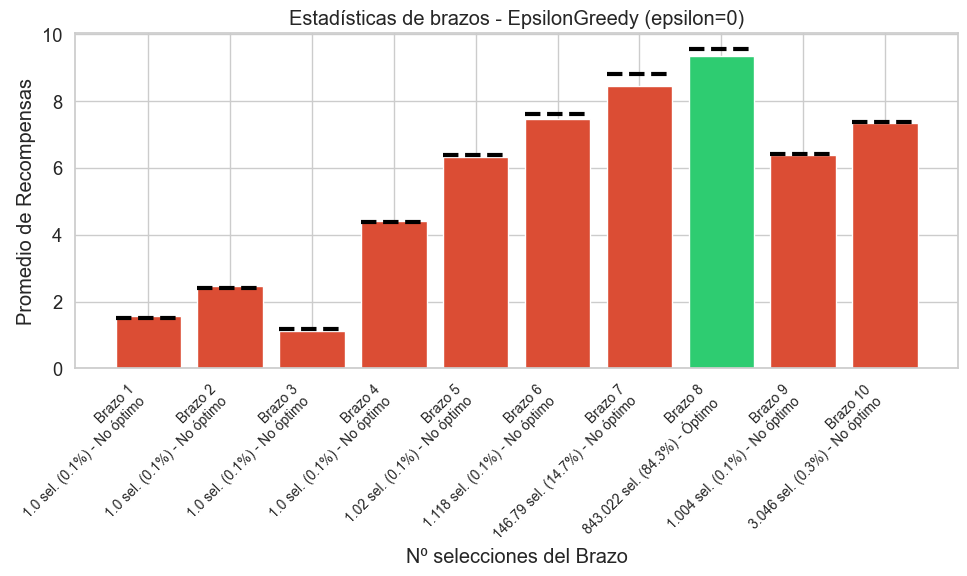


Estadísticas de brazos - EpsilonGreedy (epsilon=0.01)
Brazo 1: Recompensa Promedio = 1.5536, Selecciones = 1.95
Brazo 2: Recompensa Promedio = 2.3755, Selecciones = 1.99
Brazo 3: Recompensa Promedio = 1.1359, Selecciones = 1.964
Brazo 4: Recompensa Promedio = 4.4567, Selecciones = 1.96
Brazo 5: Recompensa Promedio = 6.4326, Selecciones = 2.028
Brazo 6: Recompensa Promedio = 7.5333, Selecciones = 2.142
Brazo 7: Recompensa Promedio = 8.6059, Selecciones = 149.82
Brazo 8: Recompensa Promedio = 9.3929, Selecciones = 834.154 (ÓPTIMO)
Brazo 9: Recompensa Promedio = 6.3954, Selecciones = 1.956
Brazo 10: Recompensa Promedio = 7.3732, Selecciones = 2.036


c:\Users\lolac\Documents\GitHub\SalasOrtegaConde1\plotting\plotting.py:232: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(x_labels, rotation=45, ha="right", fontsize=10)


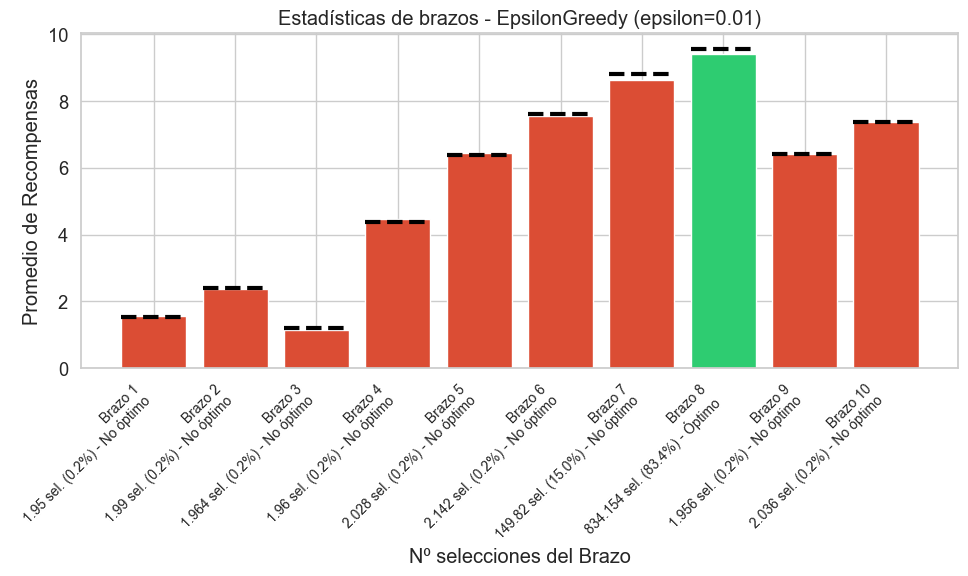

c:\Users\lolac\Documents\GitHub\SalasOrtegaConde1\plotting\plotting.py:232: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(x_labels, rotation=45, ha="right", fontsize=10)



Estadísticas de brazos - EpsilonGreedy (epsilon=0.1)
Brazo 1: Recompensa Promedio = 1.5179, Selecciones = 10.716
Brazo 2: Recompensa Promedio = 2.3921, Selecciones = 10.808
Brazo 3: Recompensa Promedio = 1.2018, Selecciones = 10.744
Brazo 4: Recompensa Promedio = 4.3687, Selecciones = 10.922
Brazo 5: Recompensa Promedio = 6.3924, Selecciones = 10.886
Brazo 6: Recompensa Promedio = 7.5922, Selecciones = 11.242
Brazo 7: Recompensa Promedio = 8.7567, Selecciones = 44.094
Brazo 8: Recompensa Promedio = 9.5571, Selecciones = 868.702 (ÓPTIMO)
Brazo 9: Recompensa Promedio = 6.4237, Selecciones = 10.804
Brazo 10: Recompensa Promedio = 7.3821, Selecciones = 11.082


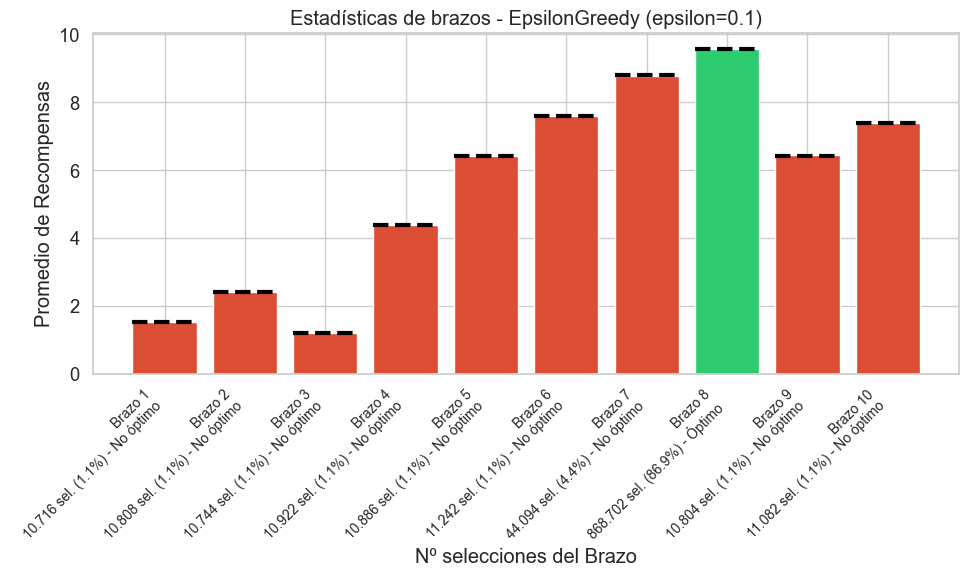

In [5]:
plot_arm_statistics(arm_stats, algorithms, [bandit.get_expected_value(i) for i in range(k)])

##### **1.1 Análisis Histogramas selección de brazos**

Estas tres gráficas muestras los diferentes histográmas de cada algoritmo, mostrándose el número de veces que ha elegido cada algoritmo a cada brazo del bandido, además de mostrar la recompensa promedia y el brazo óptimo final.

1. **Histograma ε=0**: Es el primer histograma. Cada brazo se ha seleccionado un mínimo de 0.1%, correspondiente al inicio del algoritmo, donde se selecciona una vez cada brazo. El brazo óptimo se selecciona un 84% de las veces, seguido del brazo número 7, el brazo subóptimo con mayor recompensa media, que se selecciona en un 14% de las ocasiones.

3. **Histograma ε=0.01**: Es el segundo histograma. Cada brazo se ha seleccionado aproximadamente un 2%. Esto corresponde con el porcentaje de exploración, dado que si el algoritmo explora un 1% de los pasos, y hay un total de 10 brazos, cada brazo se debería seleccionar un 0.1% de las ocasiones. El 0.1% restante se corresponde con el inicio del algoritmo. El brazo óptimo se selecciona un 83% de las veces, seguido del brazo número 7, que se selecciona en un 15% de las ocasiones.

3. **Histograma ε=0.1**: Es el tercer histograma. Cada brazo se ha seleccionado aproximadamente un 1.1%. Esto corresponde con el porcentaje de exploración del algoritmo (10%). El 0.1% restante se corresponde con el inicio del algoritmo. El brazo óptimo se selecciona un 86% de las veces, seguido del brazo número 7, que se selecciona en un 4% de las ocasiones.

Como **conclusiones** de estos histogramas:
* El algoritmo **ε-greedy con `ε=0.1`** es el que más veces selecciona el brazo óptimo, pero los porcentajes de selección del brazo óptimo en los algoritmos son muy cercanos.
* Todos los algoritmos seleccionan cada brazo al menos una vez, lo que es de ayuda en la fase de explotación. Esto se refleja sobretodo en el algoritmo con `ε=0`, que consigue seleccionar el brazo óptimo un porcentaje elevado de veces a pesar de no tener fase de exploración al terminar esta selección inicial.

A continuación, se analizan los boxplots de las estimaciones de recompensas de cada brazo para cada algoritmo.

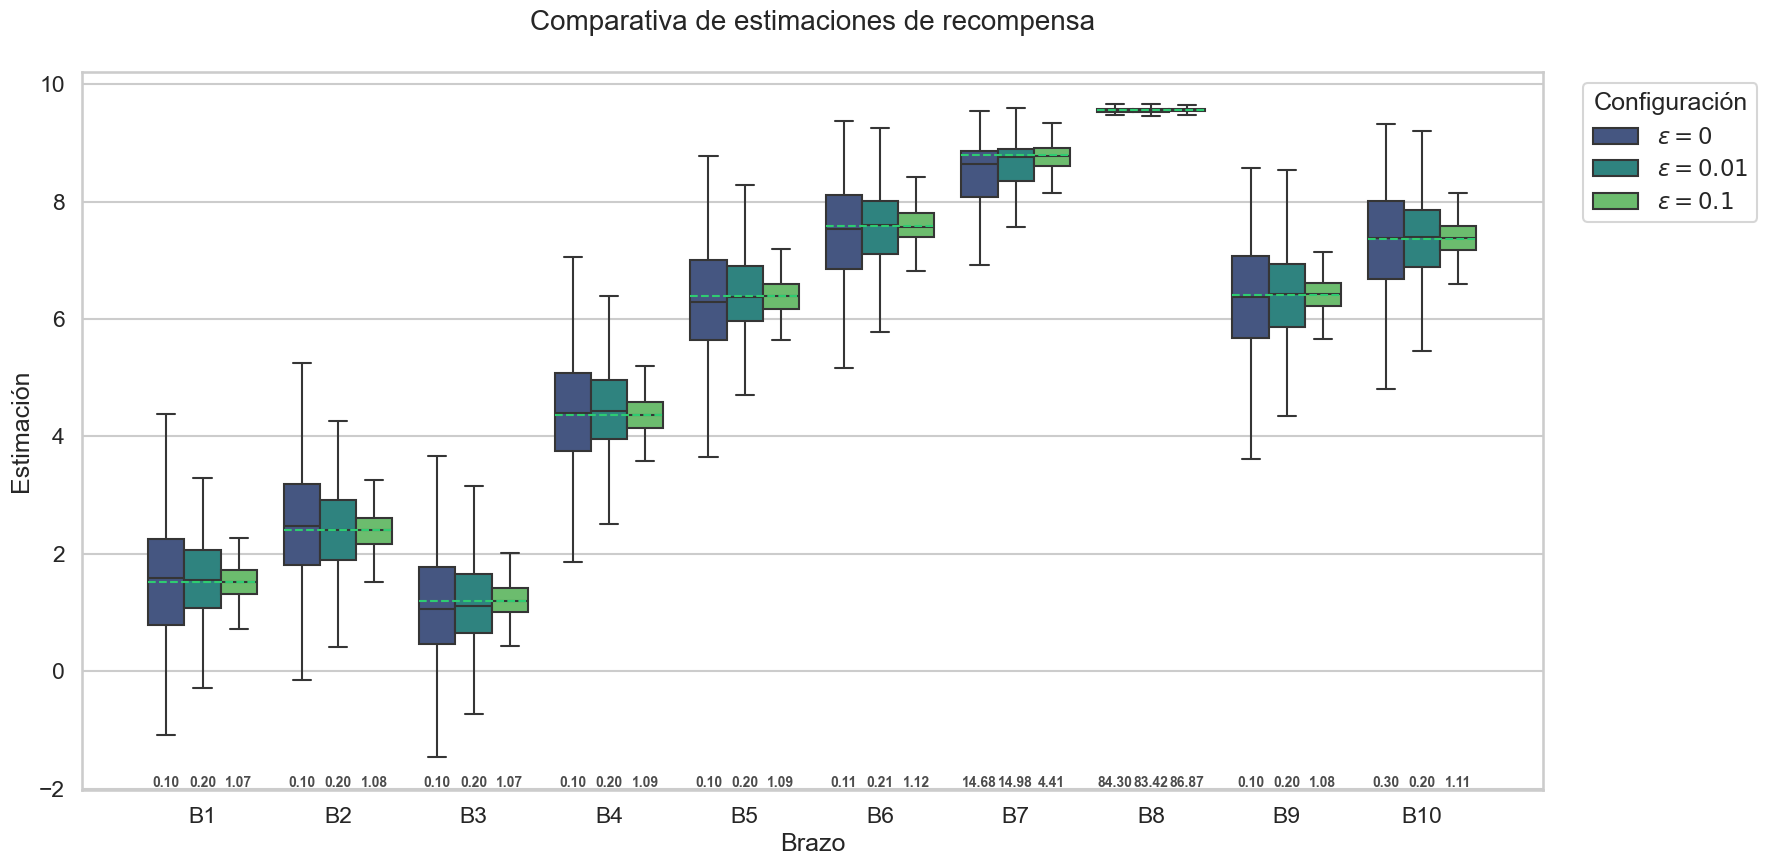

In [6]:
boxplot_estimaciones_brazos(all_runs_data, all_runs_counts, algorithms, [bandit.get_expected_value(i) for i in range(k)])

##### **1.2 Análisis Boxplots de estimaciones de recompensas de cada brazo**

Se presenta un boxplot que muestra las estimaciones finales del valor esperado de cada brazo para cada algoritmo. La media real de la distribución normal de cada brazo se muestra con una **línea verde**, por lo que cuanto más cercano a esta línea y más estrecho sea el boxplot, más precisa será la estimación.

* **Algoritmo 1 (ε-greedy con ε=0)**: Este algoritmo presenta distribuciones más anchas para la mayoría de brazos debido a que se selecciona un menor número de veces cada brazo. Respecto al brazo 7 y 8, al seleccionarse un mayor número de veces, la distribución es más estrecha

* **Algoritmo 2 (ε-greedy con ε=0.01)**: Este algoritmo presenta distribuciones más estrechas que el anterior para la mayoría de brazos debido a que se selecciona un mayor número de veces cada brazo (0.2% frente a 0.1%). Respecto al brazo 7 y 8, al seleccionarse un mayor número de veces, la distribución es más estrecha.

* **Algoritmo 3 (ε-greedy con ε=0.1)**: Este algoritmo presenta las distribuciones más estrechas, y ejecuta cada brazo aproximadamente un mínimo de 1.1%. El brazo 8, al seleccionarse un gran número de veces, la distribución es muy estrecha.

Como **conclusiones** de esta gráfica, se observa que los brazos seleccionados con menor frecuencian tienen estimaciones más variables, distribuidas alrededor de la media de la distribución de dicho brazo. Esto muestra la relevancia de ε para la estimación de las recompensas. Además, se espera que los intervalos de ε=0.01 y ε=0.1 sigan haciéndose más estrechos con el tiempo por su componente exploratoria.

A continación, se muestra la recompensa promedio que obtiene cada algoritmo a lo largo del tiempo.

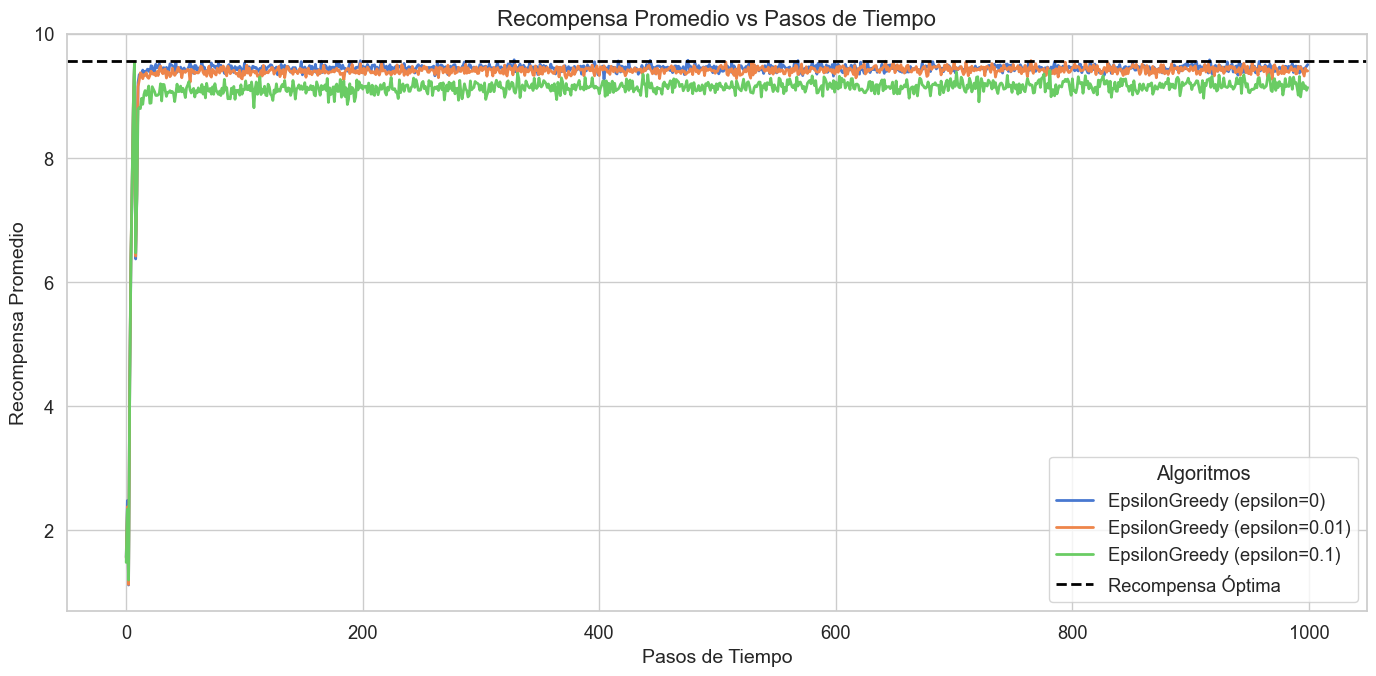

In [7]:
plot_average_rewards(steps, rewards, algorithms, optimal_reward=bandit.get_expected_value(bandit.optimal_arm))

##### **1.3 Análisis Recompensa promedio**

La gráfica muestra la recompensa promedia de los tres algoritmos de **ε-greedy** con distinto valor de **ε** durante los pasos de la ejecución. En el eje **x** se muestra los pasos de tiempo que van desde $0$ hasta $1000$ y en el eje **y** se muestra las recompensas promedio obtenidas en cada paso que van desde $0$ hasta $10$. La **línea discontinua negra** representa la recompensa del brazo óptimo.

Al inicio el algoritmo tiene una pendiente muy pronunciada por la fase de inicialización del algoritmo, en la que se selecciona cada brazo una vez. Se observa que los algoritmos rápidamente convergen a una recompensa media estable, en un valor cercano al 9.5, lo que corresponde con la media de distribución de recompensas del brazo óptimo, un 9.56.

Se ven las siguientes diferencias entre algoritmos:

* **Línea azul (ε-greedy con `ε=0`)**: Tras la fase de inicialización, este algoritmo sólo explota. Se muestra la importancia de esta fase de exploración inicial, al conseguir una recompensa promedio alta.

* **Línea naranja (ε-greedy con `ε=0.01`)**: Este algoritmo explora un 1% de los pasos. Este brazo obtiene una recompensa similar al brazo anterior.

* **Línea verde (ε-greedy con `ε=0.1`)**: Vemos como el algoritmo con ε=0.1 consigue un promedio de recompensas menor. Esto podría deberse a que este algoritmo tiene una mayor tasa de exploración, por lo que, en el punto en el que los algoritmos con ε=0.1 y ε=0.01 convergen y seleccionan el brazo óptimo, el algoritmo con ε=0.1 escoge brazos subóptimos un 10% de las ocasiones, frente al 1% del algoritmo con ε=0.01.

A continuación, se muestra el porcentaje de selección del brazo óptimo a lo largo del tiempo

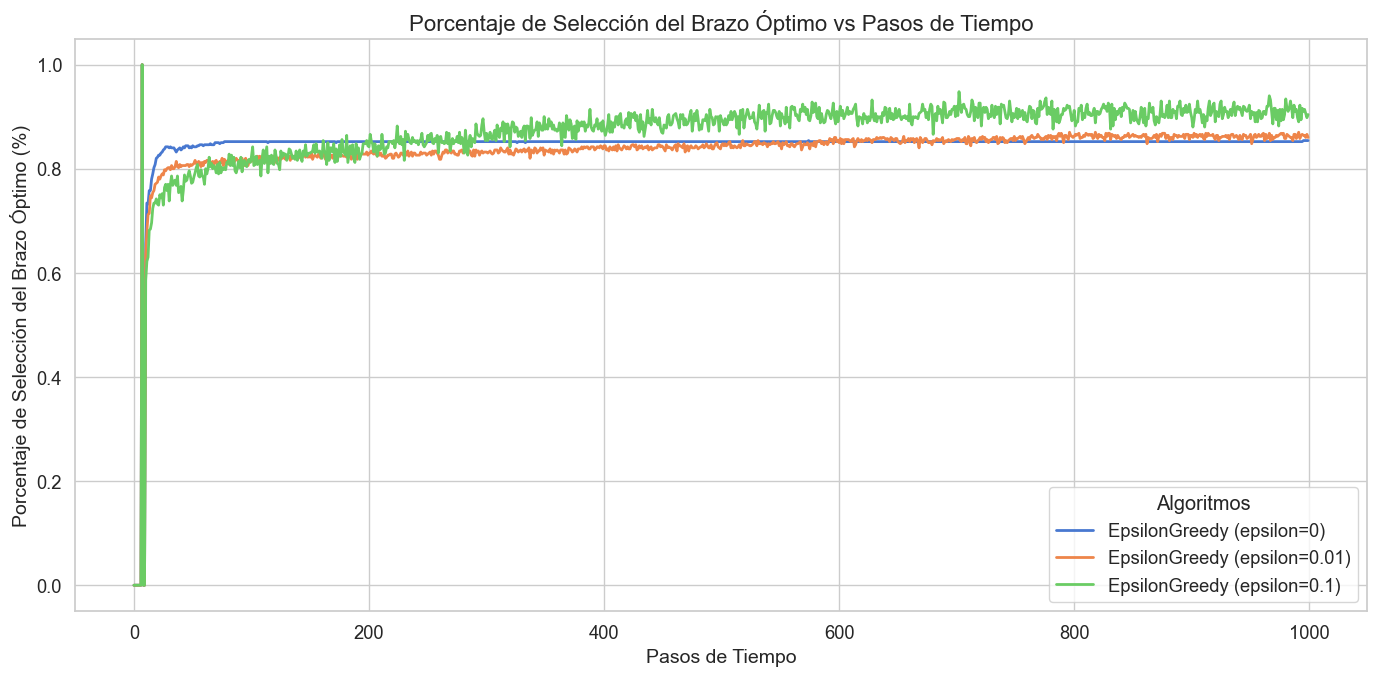

In [8]:
plot_optimal_selections(steps, optimal_selections, algorithms)

##### **1.4 Análisis Porcentaje selección óptimo**

Esta gráfica muestra la **evolución del porcentaje de selección del brazo óptimo** durante la ejecución. En el eje **x** aparece el número de pasos de tiempo que realizar cada algoritmo, de $0$ a $1000$, y en el eje **y** aparece el porcentaje de selección del brazo óptimo, de $0$ a $1$.

* **Línea azul (ε-greedy con `ε=0`)**: El porcentaje se estabiliza pronto, manteniéndose estable a partir de 100 pasos. Esto se debe a que, si el algoritmo selecciona un brazo subóptimo, no descubrirá el brazo óptimo por la falta de exploración.

* **Línea naranja (ε-greedy con `ε=0.01`)**: El porcentaje de ocasiones en los que se escoge el brazo óptimo sube con el tiempo a un ritmo constante.

* **Línea verde (ε-greedy con `ε=0.1`)**: El porcentaje de ocasiones en los que se escoge el brazo óptimo aumenta más rápido que con ε=0.01, dada su mayor tasa de exploración, que permite identificar antes el brazo óptimo. La curva se estabiliza alrededor del 90%, debido a que el algoritmo explora un 10% de las ocasiones.

Se espera que, si se ejecuta un mayor número de pasos, el algoritmo con ε=0.01 termine superando al algoritmo con ε=0.1, dado que explora un 1% de las ocasiones, por lo que al identificar el brazo óptimo, lo explota con mayor frecuencia.

A continuación, se muestra el regret acumulado durante los pasos del tiempo. 

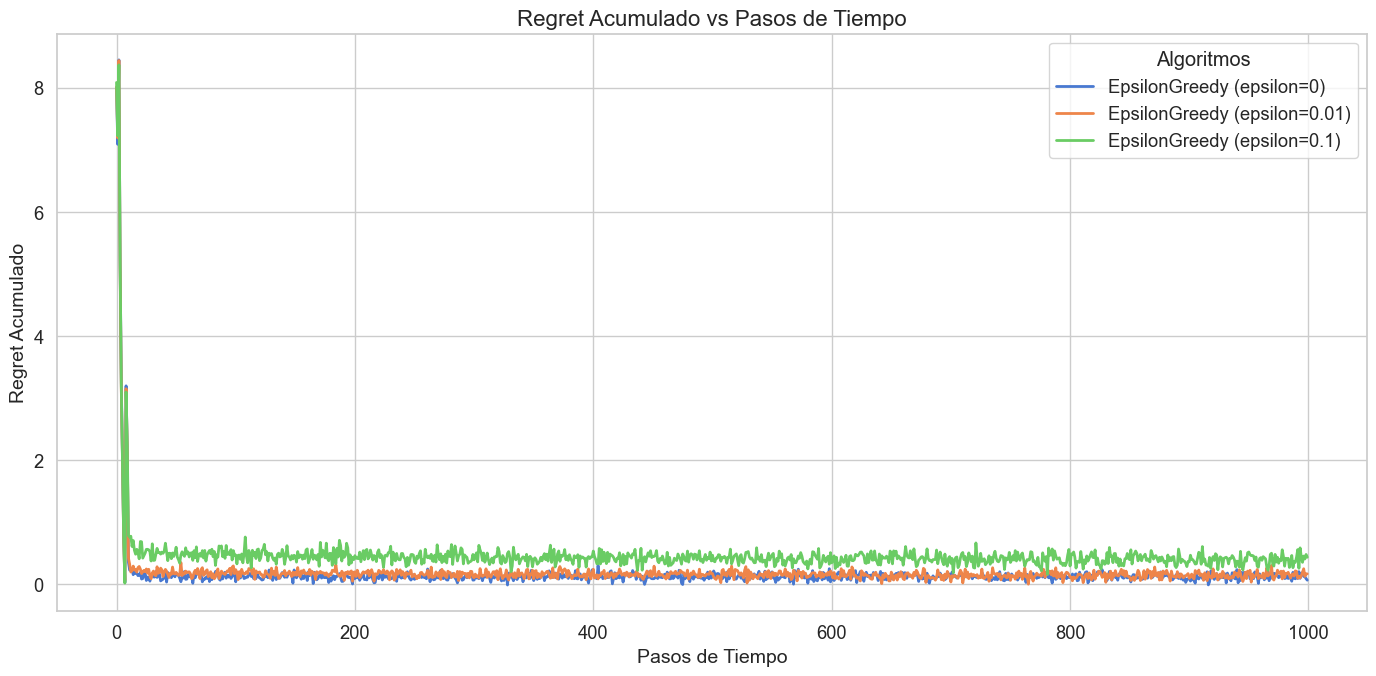

In [9]:
plot_regret(steps, regrets, algorithms)

##### **1.5 Análisis arrepentimiento acumulado**

Esta gráfica muestra la **evolución del arrepentimiento acumulado** de cada algoritmo. En el eje **x** aparece el número de pasos de tiempo que realizar cada algoritmo, de $0$ a $1000$, y en el eje **y** aparece el arrepentimiento acumulado, desde $0$ hasta $9$. La diferencia de las dos primeras gráficas es que ahora se busca disminuir el valor de arrepentimiento acumulado.

* **Línea azul (ε-greedy con `ε=0`)**: Muestra la evolución del arrepentimiento acumulado usando el algoritmo que tras la fase de inicialización sólo explota. Dado que el algoritmo tiende a converger al brazo óptimo y en menor porcentaje al segundo brazo con mayor recompensa media, su regret, aunque no es cero, es cercano al 0.

* **Línea naranja (ε-greedy con `ε=0.01`)**: Dado que el algoritmo con ε=0.01 tiene una recompensa media mayor, obtiene un regret bajo.

* **Línea verde (ε-greedy con `ε=0.1`)**: Aunque el algoritmo con ε=0.1 descubre antes el brazo óptimo por su tasa de exploración, selecciona brazos subóptimos con más frecuencia, lo que incrementa su regret. 

    El algoritmo con ε=0.01 tarda más tiempo en identificar el brazo óptimo, y un 14% de las ocasiones selecciona el brazo 7, que es el segundo con media mayor de recompensa, frente al 4% del algoritmo con ε=0.1. Sin embargo, el regret añadido por esas decisiones es menor que el añadido por el 10% de exploración del algoritmo con ε=0.1, donde selecciona brazos con recompensas medias mucho menores.

### **``2. Experimento distribución Bernoulli``**

A continuación, se realiza el experimento con un bandido cuyas recompensas de cada brazo siguen una distribución de Bernuilli. Se comparan los algoritmos ε greedy con ε=0, ε=0.1, y ε=0.01.

In [10]:
# Creación del bandit
bandit = Bandit(arms=ArmBernoulli.generate_arms(k)) # Generar un bandido con k brazos de distribución de Bernoulli
print(bandit)

optimal_arm = bandit.optimal_arm
print(f"Optimal arm: {optimal_arm + 1} with expected reward={bandit.get_expected_value(optimal_arm)}")

# Definir los algoritmos a comparar. En este caso son 3 algoritmos epsilon-greedy con diferentes valores de epsilon.
algorithms = [EpsilonGreedy(k=k, epsilon=0), EpsilonGreedy(k=k, epsilon=0.01), EpsilonGreedy(k=k, epsilon=0.1)]

# Ejecutar el experimento y obtener las recompensas promedio, porcentaje de selecciones óptimas y estadísticas de brazos
rewards, optimal_selections, arm_stats, regrets, all_runs_data, all_runs_counts  = run_experiment(bandit, algorithms, steps, runs)

Bandit with 10 arms: ArmBernoulli(p=0.7), ArmBernoulli(p=0.35), ArmBernoulli(p=0.79), ArmBernoulli(p=0.34), ArmBernoulli(p=0.42), ArmBernoulli(p=0.08), ArmBernoulli(p=0.68), ArmBernoulli(p=0.69), ArmBernoulli(p=0.65), ArmBernoulli(p=0.73)
Optimal arm: 3 with expected reward=0.79


#### **Visualización**

En esta apartado vamos a mostrar y analizar las diferentes gráficas generadas para el experimento del bandido de k-brazos con distribución normal. Las gráficas que se van mostrar son las siguientes:

* Número de veces que se ha seleccionado cada brazo en el experimento
* Boxplots de las estimaciones de recompensa por cada brazo.
* Evolución de la recompensa promedio durante el experimento
* Evolución del porcentaje de la selección del mejor brazo
* Evolución del arrepentimiento durante el experimento


Para empezar, se analiza las estadísticas de la selección de cada brazo para cada algoritmo.


Estadísticas de brazos - EpsilonGreedy (epsilon=0)
Brazo 1: Recompensa Promedio = 0.4257, Selecciones = 118.11
Brazo 2: Recompensa Promedio = 0.1694, Selecciones = 1.91
Brazo 3: Recompensa Promedio = 0.5467, Selecciones = 418.956 (ÓPTIMO)
Brazo 4: Recompensa Promedio = 0.1981, Selecciones = 3.908
Brazo 5: Recompensa Promedio = 0.2321, Selecciones = 2.084
Brazo 6: Recompensa Promedio = 0.0413, Selecciones = 1.084
Brazo 7: Recompensa Promedio = 0.4313, Selecciones = 92.392
Brazo 8: Recompensa Promedio = 0.4255, Selecciones = 105.204
Brazo 9: Recompensa Promedio = 0.3936, Selecciones = 63.25
Brazo 10: Recompensa Promedio = 0.4501, Selecciones = 193.102


c:\Users\lolac\Documents\GitHub\SalasOrtegaConde1\plotting\plotting.py:232: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(x_labels, rotation=45, ha="right", fontsize=10)


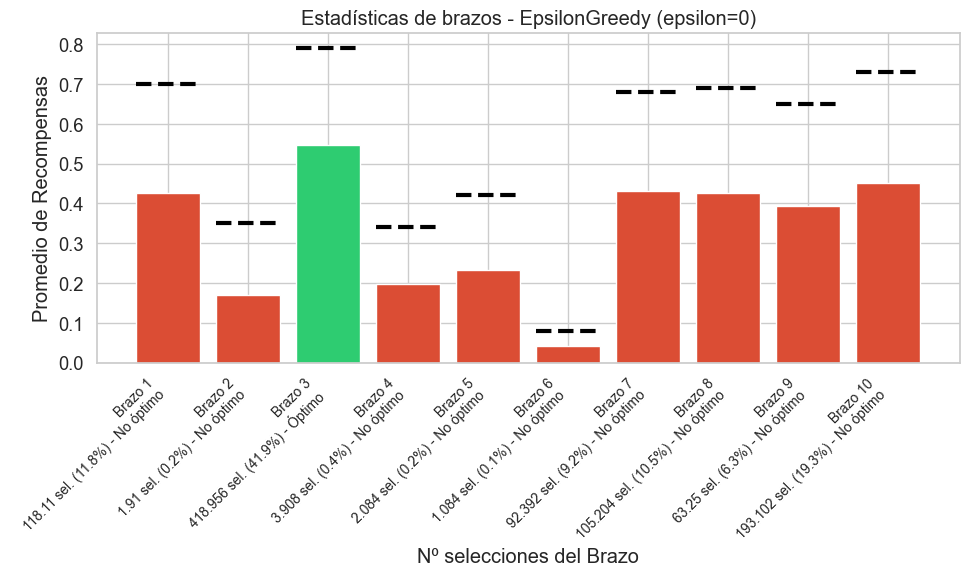


Estadísticas de brazos - EpsilonGreedy (epsilon=0.01)
Brazo 1: Recompensa Promedio = 0.4985, Selecciones = 117.634
Brazo 2: Recompensa Promedio = 0.2546, Selecciones = 2.626
Brazo 3: Recompensa Promedio = 0.6388, Selecciones = 476.852 (ÓPTIMO)
Brazo 4: Recompensa Promedio = 0.2403, Selecciones = 2.744
Brazo 5: Recompensa Promedio = 0.2767, Selecciones = 2.94
Brazo 6: Recompensa Promedio = 0.0572, Selecciones = 2.056
Brazo 7: Recompensa Promedio = 0.5070, Selecciones = 76.946
Brazo 8: Recompensa Promedio = 0.5119, Selecciones = 96.666
Brazo 9: Recompensa Promedio = 0.4951, Selecciones = 35.706
Brazo 10: Recompensa Promedio = 0.5535, Selecciones = 185.83


c:\Users\lolac\Documents\GitHub\SalasOrtegaConde1\plotting\plotting.py:232: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(x_labels, rotation=45, ha="right", fontsize=10)


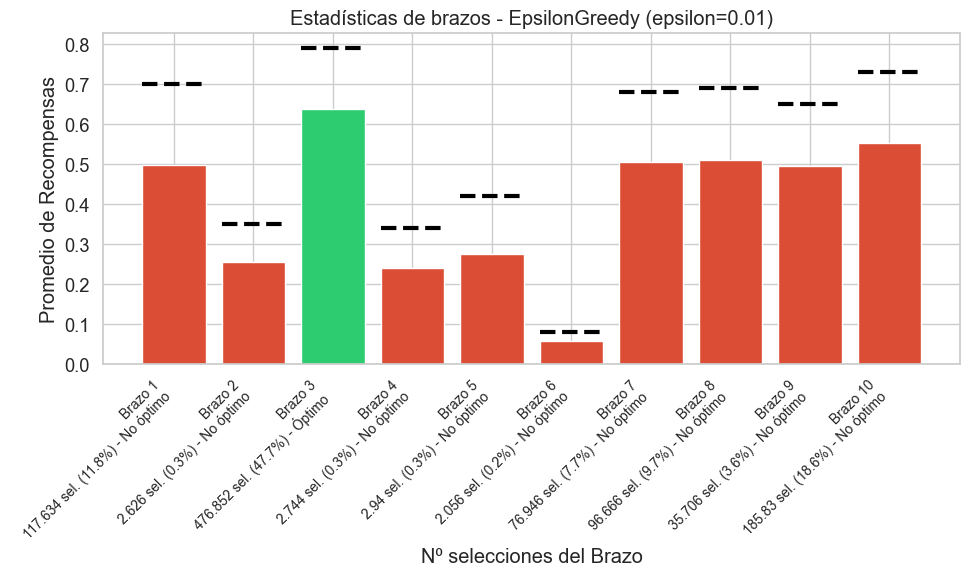

c:\Users\lolac\Documents\GitHub\SalasOrtegaConde1\plotting\plotting.py:232: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(x_labels, rotation=45, ha="right", fontsize=10)



Estadísticas de brazos - EpsilonGreedy (epsilon=0.1)
Brazo 1: Recompensa Promedio = 0.6446, Selecciones = 93.202
Brazo 2: Recompensa Promedio = 0.3278, Selecciones = 11.71
Brazo 3: Recompensa Promedio = 0.7500, Selecciones = 523.814 (ÓPTIMO)
Brazo 4: Recompensa Promedio = 0.3335, Selecciones = 11.79
Brazo 5: Recompensa Promedio = 0.4109, Selecciones = 12.382
Brazo 6: Recompensa Promedio = 0.0744, Selecciones = 10.862
Brazo 7: Recompensa Promedio = 0.6370, Selecciones = 61.016
Brazo 8: Recompensa Promedio = 0.6415, Selecciones = 74.11
Brazo 9: Recompensa Promedio = 0.6168, Selecciones = 33.408
Brazo 10: Recompensa Promedio = 0.6746, Selecciones = 167.706


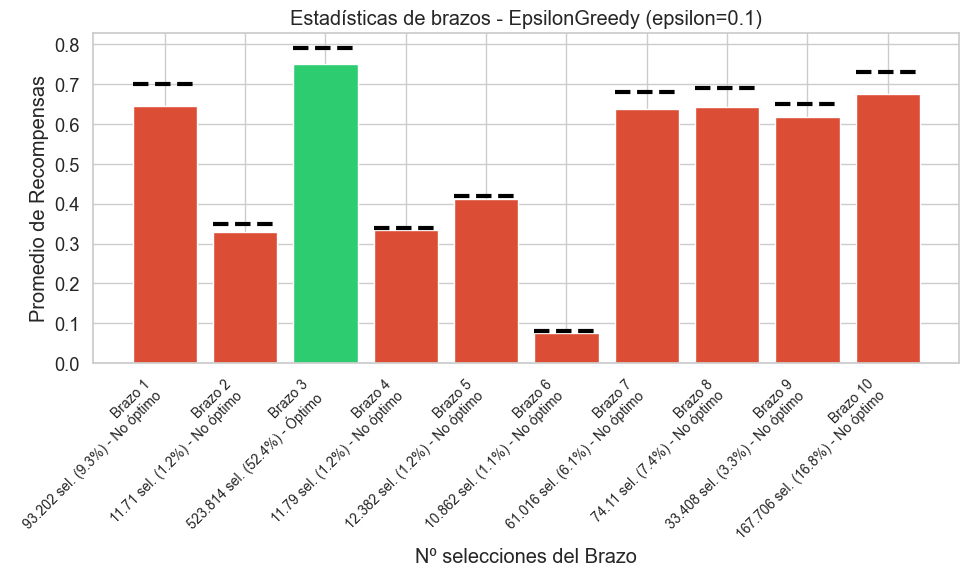

In [11]:
plot_arm_statistics(arm_stats, algorithms, [bandit.get_expected_value(i) for i in range(k)])

##### **2.1 Análisis Histogramas selección de brazos**

En primer lugar, se presenta un boxplot que muestra las estimaciones finales del valor esperado de cada brazo para cada algoritmo. La media real de la distribución normal de cada brazo se muestra con una línea verde.

Estas tres gráficas muestras los diferentes histogramas de cada algoritmo, mostrándose el número de veces que ha elegido cada algoritmo a cada brazo del bandido, además de mostrar la recompensa promedia y el brazo óptimo final.

Al seguir la distribución de Bernuilli, las recompensas son 0 o 1, por lo que se necesita un mayor número de selecciones para obtener una estimación precisa de la recompensa media.

Sin embargo, los brazos con media real de recompensa mayor al 50% tienen medias cercanas, siendo la diferencia entre el brazo óptimo y los subóptimos del 10% aproximadamente. Esto genera confusiones entre los brazos, llegando a un 41% de selección del brazo óptimo con ε=0, y aproximadamente un 50% con ε=0.01 y ε=0.1.

1. **Histograma ε=0**: Es el primer histograma. Cada brazo se ha seleccionado un mínimo de 0.1%, correspondiente al inicio del algoritmo. Los brazos con media real de recompensa mayor al 50% tienen medias cercanas, siendo la diferencia entre el brazo óptimo y los subóptimos del 10% aproximadamente. Esto genera confusiones entre los brazos, generando que el brazo óptimo se seleccione un 41% de las ocasiones.

3. **Histograma ε=0.01**: Es el segundo histograma. Cada brazo se ha seleccionado un mínimo de un 0.2%, por su tasa de exploración y la selección inicial. Este algoritmo, con mayor tasa de exploración que con ε=0, selecciona el brazo óptimo un mayor número de veces, un 47.7%.

3. **Histograma ε=0.1**: Es el tercer histograma. Cada brazo se ha seleccionado un mínimo de un 1.1%, por su tasa de exploración y la selección inicial. Este algoritmo, con la mayor tasa de exploración, selecciona el brazo óptimo un mayor numero de veces, un 52.4%. Además, la estimación media de cada brazo se aproxima mejor a la real.

Como **conclusiones** de estos histogramas, la distribución de Bernuilli da menor información en cada selección que la distribución normal, lo que se ve reflejado en una peor estimación de la estimación media de cada brazo, y una peor selección del mejor brazo. Esto también se podría ver afectado por el alto número de brazos con media cercana al brazo óptimo, que dificulta la convergencia de los algoritmos a este brazo. Se observa como, con menos información en cada paso y distribuciones más cercanas, el algoritmo con ε=0 selecciona el brazo óptimo un menor número de ocasiones.

A continuación, se analizan los boxplots de las estimaciones de recompensas de cada brazo para cada algoritmo.

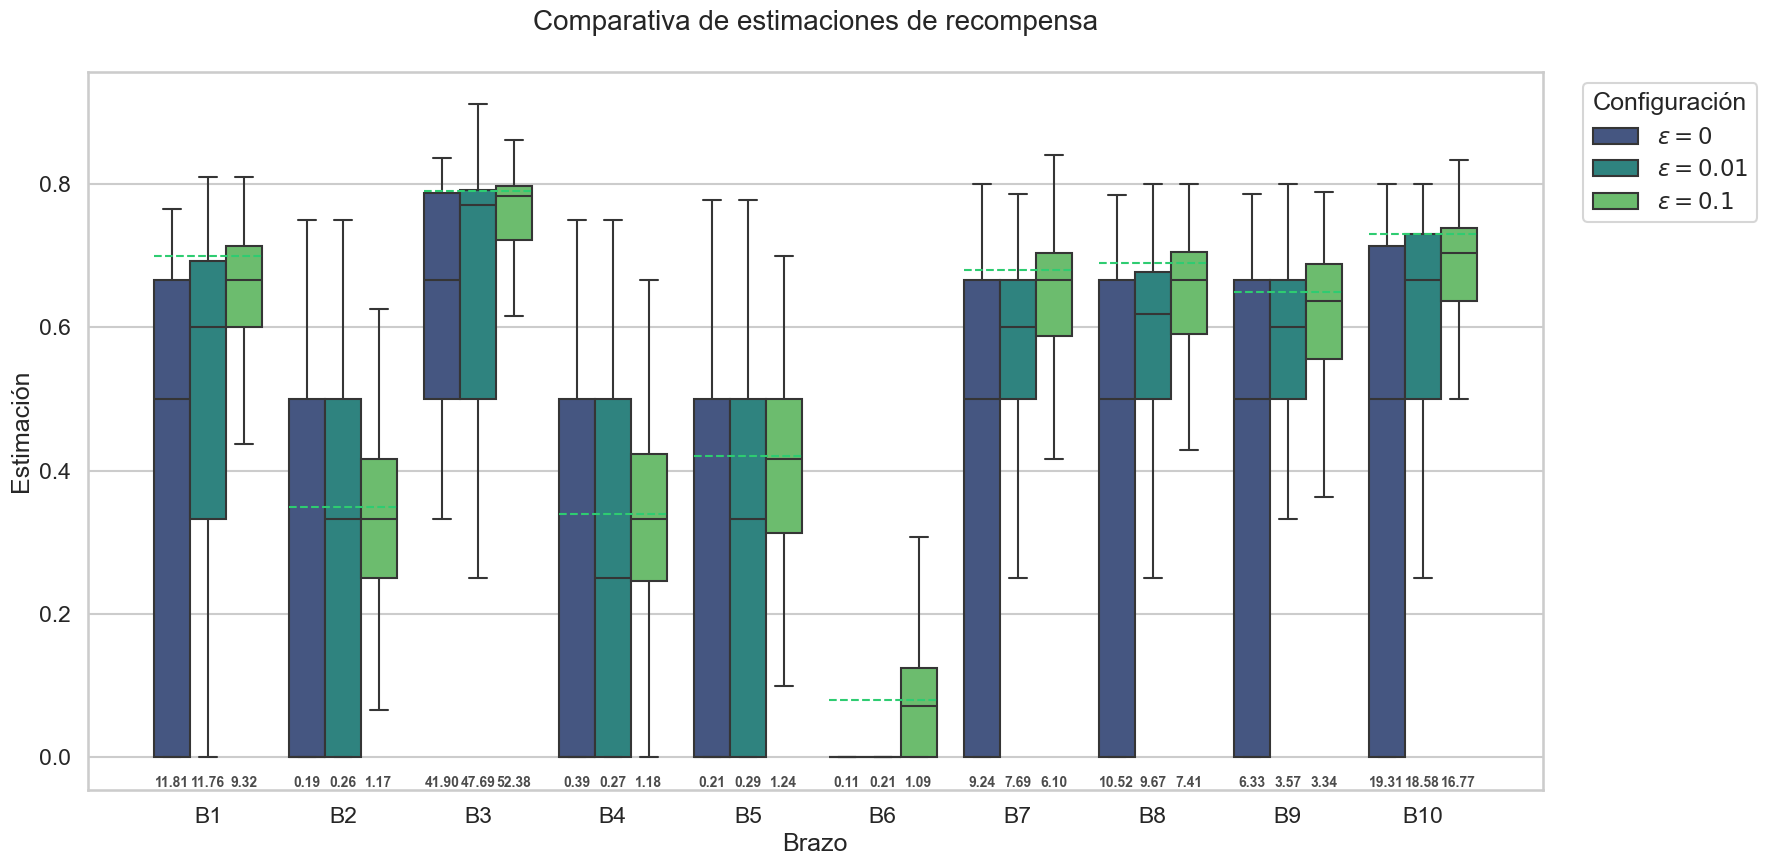

In [12]:
boxplot_estimaciones_brazos(all_runs_data, all_runs_counts, algorithms, [bandit.get_expected_value(i) for i in range(k)])

##### **2.2 Análisis Boxplots de estimaciones de recompensas de cada brazo**

En primer lugar, se presenta un boxplot que muestra las estimaciones finales del valor esperado de cada brazo para cada algoritmo. La media real de la distribución normal de cada brazo se muestra con una **línea verde**, por lo que cuanto más cercano a esta línea y más estrecho sea el boxplot, más precisa será la estimación.

* **Algoritmo 1 (ε-greedy con ε=0)**: Este algoritmo presenta distribuciones más anchas para la mayoría de brazos. Además, las distribuciones de la estimación de recompensa de los brazos no óptimos tiene un mínimo de 0. Dado que la distribución de Bernuilli devuelve valores 0 o 1, si estos brazos devuelven 0 en la selección inicial, no vuelven a ser seleccionados, y su estimación final es 0. 

* **Algoritmo 2 (ε-greedy con ε=0.01)**: Este algoritmo presenta distribuciones más estrechas que el anterior para los brazos con media de estimación mayor a 0.5. 

* **Algoritmo 3 (ε-greedy con ε=0.1)**: Este algoritmo presenta las distribuciones más estrechas, dado que tiene una mayor exploración en todas las ejecuciones, lo que permite una estimación más exacta de la recompensa de cada brazo.

Como **conclusiones** de esta gráfica, se observa que a mayor tasa de exploración, las distribuciones de las estimaciones son más estrechas.

A continación, se muestra la recompensa promedio que obtiene cada algoritmo a lo largo del tiempo.

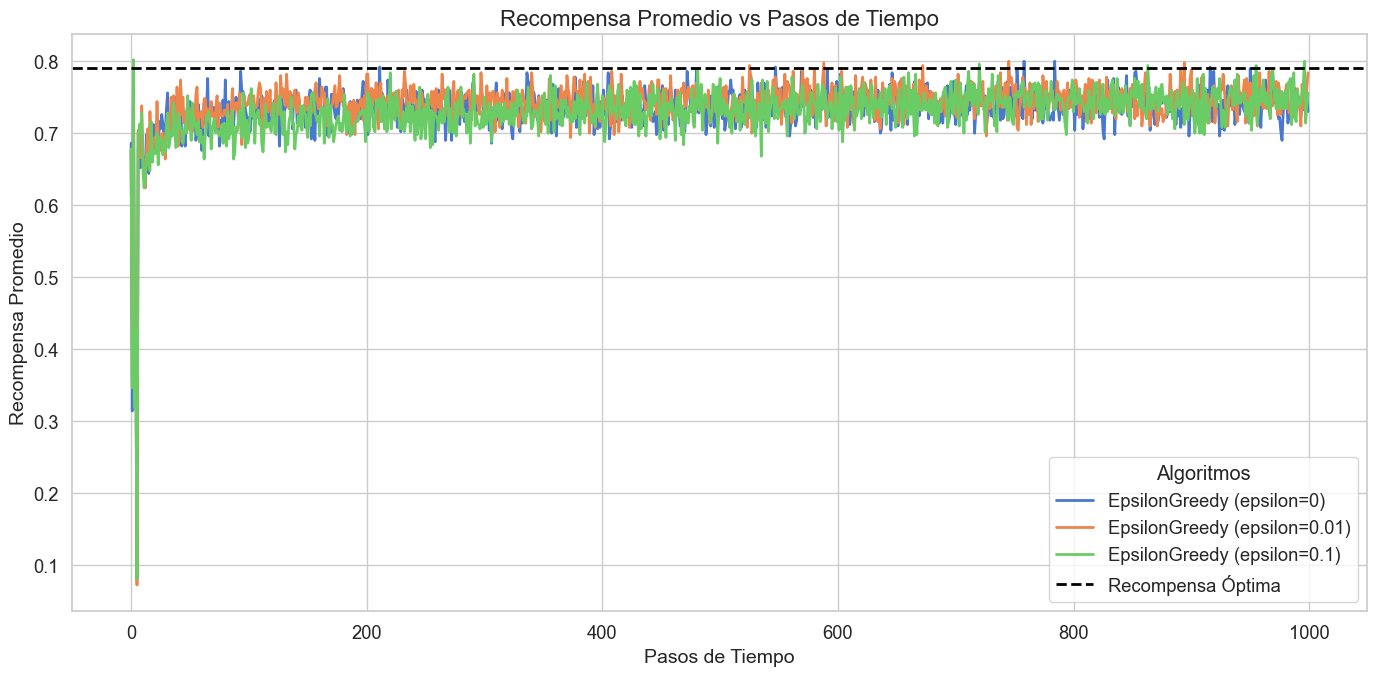

In [13]:
plot_average_rewards(steps, rewards, algorithms, optimal_reward=bandit.get_expected_value(bandit.optimal_arm))

##### **2.3 Análisis Recompensa promedio**

La gráfica muestra la recompensa promedia de los tres algoritmos de **ε-greedy** con distinto valor de **ε** durante los pasos de la ejecución. En el eje **x** se muestra los pasos de tiempo que van desde $0$ hasta $1000$ y en el eje **y** se muestra las recompensas promedio obtenidas en cada paso que van desde $0$ hasta $0.8$. La **línea discontinua negra** representa la recompensa del brazo óptimo.

Al inicio el algoritmo tiene una pendiente muy pronunciada por la fase de inicialización del algoritmo, en la que se selecciona cada brazo una vez. Se observa que la recompensa promedio obtenida es similar en todos los algoritmos, entre el 0.7 y el 0.8. Este valor es coherente con frecuencia de elección del brazo óptimo (cercano al 50%, con recompensa media de 0.79), y la elección frecuente de brazos con media cercana a 0.7.

A continuación, se muestra el porcentaje de selección del brazo óptimo a lo largo del tiempo

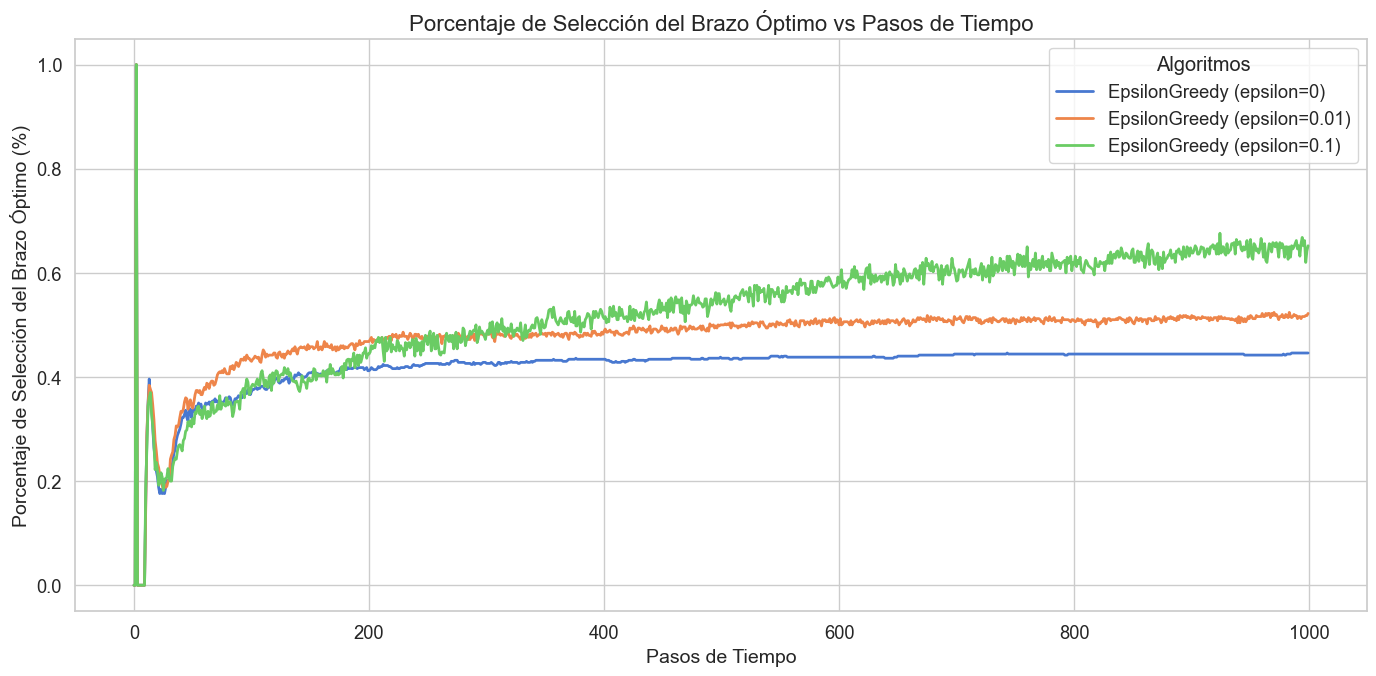

In [14]:
plot_optimal_selections(steps, optimal_selections, algorithms)

##### **2.4 Análisis Porcentaje selección óptimo**

Esta gráfica muestra la **evolución del porcentaje de selección del brazo óptimo** durante la ejecución. En el eje **x** aparece el número de pasos de tiempo que realizar cada algoritmo, de $0$ a $1000$, y en el eje **y** aparece el porcentaje de selección del brazo óptimo, de $0$ a $1$.

* **Línea azul (ε-greedy con `ε=0`)**: Se selecciona el brazo óptimo aproximadamente un 45% de las ocasiones. Este porcentaje se mantiene estable a partir del paso 400. Dada la falta de exploración, si el algoritmo selecciona un brazo subóptimo no descubrirá el brazo óptimo.

* **Línea naranja (ε-greedy con `ε=0.01`)**: El porcentaje de selección del brazo óptimo aumenta de forma muy lenta. Esto ocurre por su tasa de exploración, al ser un 1%, necesitará un gran número de pasos del tiempo para converger y seleccionar el brazo óptimo.

* **Línea verde (ε-greedy con `ε=0.1`)**: Se observa una subida más rápida. Esto ocurre por su tasa de exploración, al ser un 10%, es capaz de obtener más información sobre las distribuciones de probabilidad de cada brazo y converger más rápido.

A continuación, se muestra el regret acumulado durante los pasos del tiempo. 

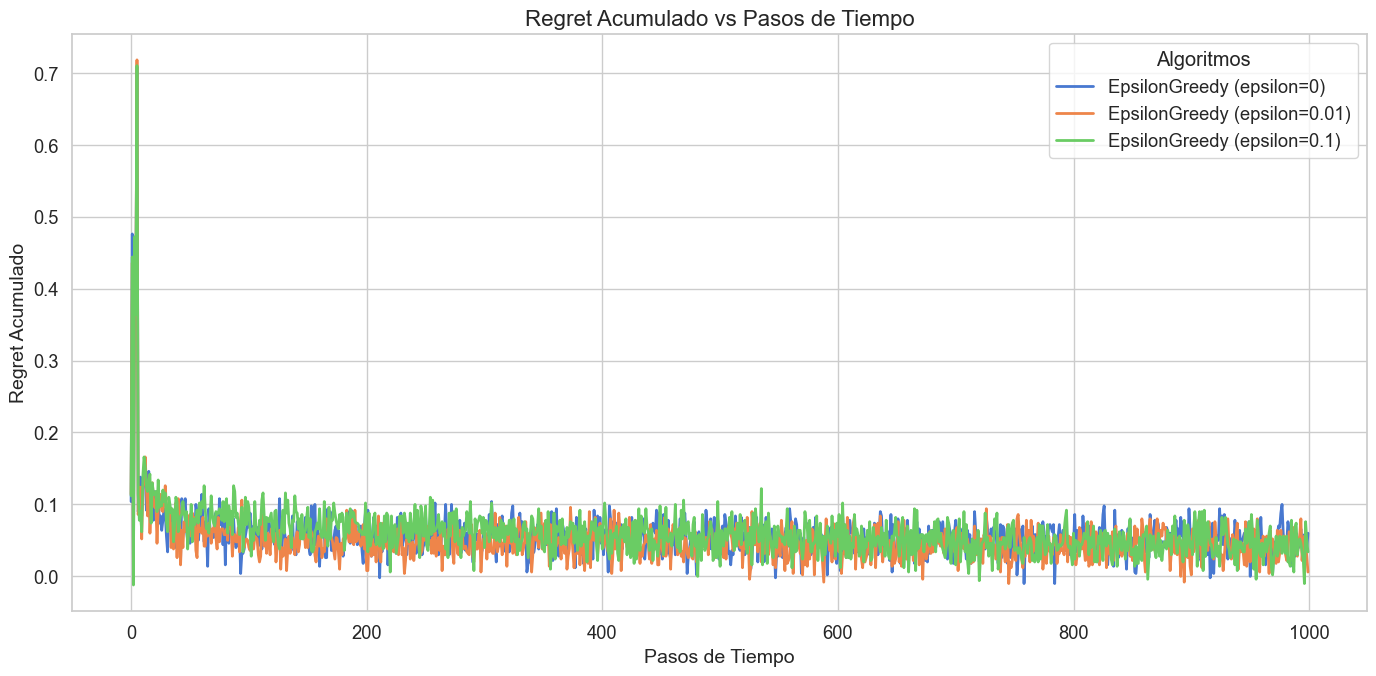

In [15]:
plot_regret(steps, regrets, algorithms)

##### **2.5 Análisis arrepentimiento acumulado**

Esta gráfica muestra la **evolución del arrepentimiento acumulado** de cada algoritmo. En el eje **x** aparece el número de pasos de tiempo que realizar cada algoritmo, de $0$ a $1000$, y en el eje **y** aparece el arrepentimiento acumulado, desde $0$ hasta $9$. La diferencia de las dos primeras gráficas es que ahora se busca disminuir el valor de arrepentimiento acumulado.

Se observa un regret similar en todos los algoritmos. Este regret es cercano al 0.05, debido a que en el componente de explotación los algoritmos dudan entre el brazo óptimo (con recompensa media de 0.8) y brazos subóptimos con recompensa media de 0.7.

### **3. ``Experimento distribución Binomial``**

A continuación, se realiza el experimento con un bandido cuyas recompensas de cada brazo siguen una distribución binomial. Se comparan los algoritmos ε greedy con ε=0, ε=0.1, y ε=0.01.

In [16]:
# Creación del bandit
bandit = Bandit(arms=ArmBinomial.generate_arms(k)) # Generar un bandido con k brazos de distribución binomial
print(bandit)

optimal_arm = bandit.optimal_arm
print(f"Optimal arm: {optimal_arm + 1} with expected reward={bandit.get_expected_value(optimal_arm)}")

# Definir los algoritmos a comparar. En este caso son 3 algoritmos epsilon-greedy con diferentes valores de epsilon.
algorithms = [EpsilonGreedy(k=k, epsilon=0), EpsilonGreedy(k=k, epsilon=0.01), EpsilonGreedy(k=k, epsilon=0.1)]

# Ejecutar el experimento y obtener las recompensas promedio, porcentaje de selecciones óptimas y estadísticas de brazos
rewards, optimal_selections, arm_stats, regrets, all_runs_data, all_runs_counts = run_experiment(bandit, algorithms, steps, runs)

Bandit with 10 arms: ArmBinomial(n=10, p=0.37), ArmBinomial(n=10, p=0.78), ArmBinomial(n=10, p=0.58), ArmBinomial(n=10, p=0.99), ArmBinomial(n=10, p=0.52), ArmBinomial(n=10, p=0.49), ArmBinomial(n=10, p=0.39), ArmBinomial(n=10, p=0.06), ArmBinomial(n=10, p=0.12), ArmBinomial(n=10, p=0.02)
Optimal arm: 4 with expected reward=9.9


#### **Visualización**

En esta apartado vamos a mostrar y analizar las diferentes gráficas generadas para el experimento del bandido de k-brazos con distribución normal. Las gráficas que se van mostrar son las siguientes:

* Número de veces que se ha seleccionado cada brazo en el experimento
* Boxplots de las estimaciones de recompensa por cada brazo.
* Evolución de la recompensa promedio durante el experimento
* Evolución del porcentaje de la selección del mejor brazo
* Evolución del arrepentimiento durante el experimento


Para empezar, se analiza las estadísticas de la selección de cada brazo para cada algoritmo.


Estadísticas de brazos - EpsilonGreedy (epsilon=0)
Brazo 1: Recompensa Promedio = 3.7600, Selecciones = 1.0
Brazo 2: Recompensa Promedio = 7.7633, Selecciones = 1.194
Brazo 3: Recompensa Promedio = 5.6977, Selecciones = 1.008
Brazo 4: Recompensa Promedio = 9.8997, Selecciones = 990.796 (ÓPTIMO)
Brazo 5: Recompensa Promedio = 5.1650, Selecciones = 1.002
Brazo 6: Recompensa Promedio = 4.9480, Selecciones = 1.0
Brazo 7: Recompensa Promedio = 3.8680, Selecciones = 1.0
Brazo 8: Recompensa Promedio = 0.5520, Selecciones = 1.0
Brazo 9: Recompensa Promedio = 1.1180, Selecciones = 1.0
Brazo 10: Recompensa Promedio = 0.2380, Selecciones = 1.0


c:\Users\lolac\Documents\GitHub\SalasOrtegaConde1\plotting\plotting.py:232: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(x_labels, rotation=45, ha="right", fontsize=10)


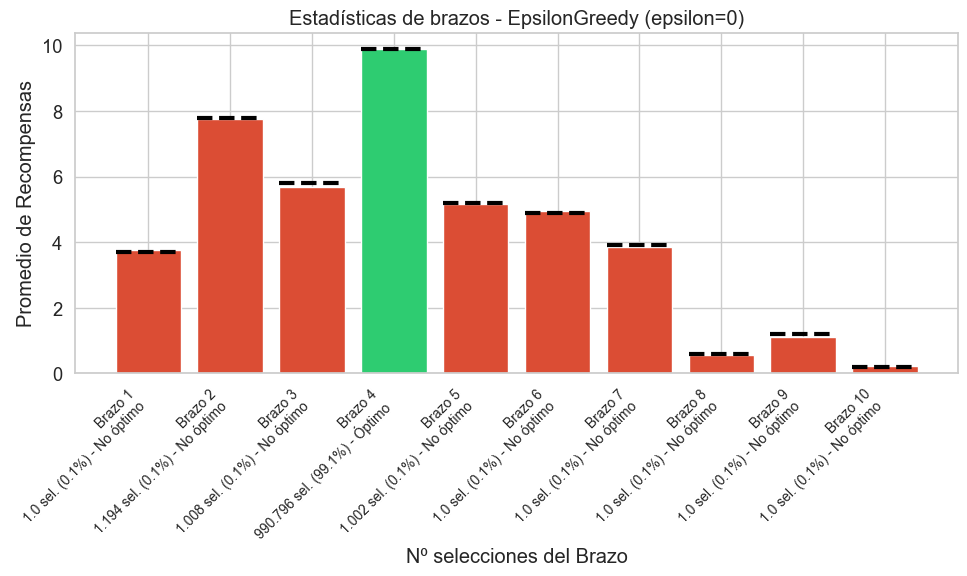


Estadísticas de brazos - EpsilonGreedy (epsilon=0.01)
Brazo 1: Recompensa Promedio = 3.7543, Selecciones = 2.014
Brazo 2: Recompensa Promedio = 7.8011, Selecciones = 2.254
Brazo 3: Recompensa Promedio = 5.6777, Selecciones = 1.924
Brazo 4: Recompensa Promedio = 9.8993, Selecciones = 981.716 (ÓPTIMO)
Brazo 5: Recompensa Promedio = 5.2808, Selecciones = 1.986
Brazo 6: Recompensa Promedio = 4.9103, Selecciones = 1.992
Brazo 7: Recompensa Promedio = 3.8908, Selecciones = 2.046
Brazo 8: Recompensa Promedio = 0.6412, Selecciones = 2.032
Brazo 9: Recompensa Promedio = 1.1531, Selecciones = 1.966
Brazo 10: Recompensa Promedio = 0.2094, Selecciones = 2.07


c:\Users\lolac\Documents\GitHub\SalasOrtegaConde1\plotting\plotting.py:232: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(x_labels, rotation=45, ha="right", fontsize=10)


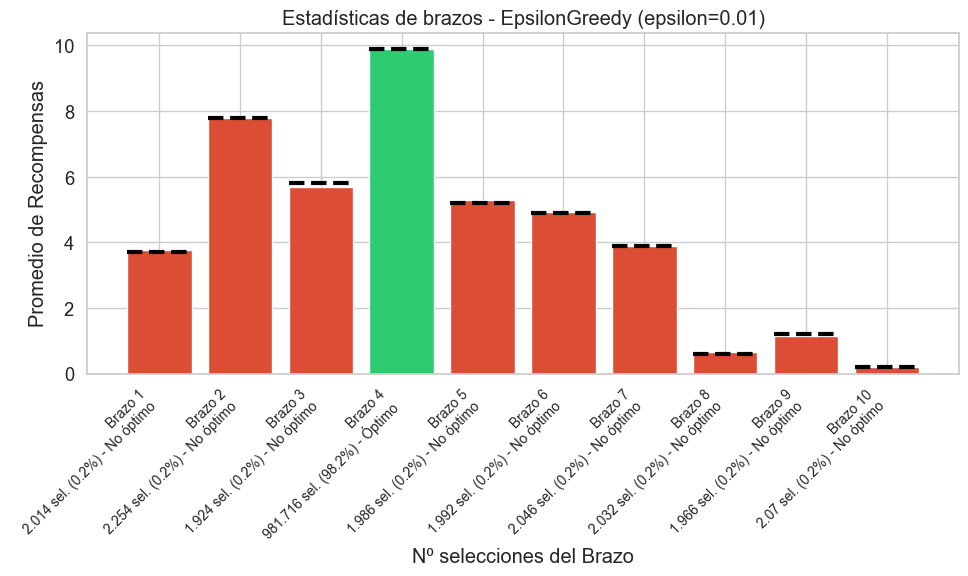

c:\Users\lolac\Documents\GitHub\SalasOrtegaConde1\plotting\plotting.py:232: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(x_labels, rotation=45, ha="right", fontsize=10)



Estadísticas de brazos - EpsilonGreedy (epsilon=0.1)
Brazo 1: Recompensa Promedio = 3.7170, Selecciones = 10.748
Brazo 2: Recompensa Promedio = 7.8139, Selecciones = 11.094
Brazo 3: Recompensa Promedio = 5.7436, Selecciones = 10.782
Brazo 4: Recompensa Promedio = 9.9002, Selecciones = 902.164 (ÓPTIMO)
Brazo 5: Recompensa Promedio = 5.1900, Selecciones = 10.858
Brazo 6: Recompensa Promedio = 4.8884, Selecciones = 10.688
Brazo 7: Recompensa Promedio = 3.8928, Selecciones = 10.91
Brazo 8: Recompensa Promedio = 0.6039, Selecciones = 10.77
Brazo 9: Recompensa Promedio = 1.1838, Selecciones = 11.02
Brazo 10: Recompensa Promedio = 0.2015, Selecciones = 10.966


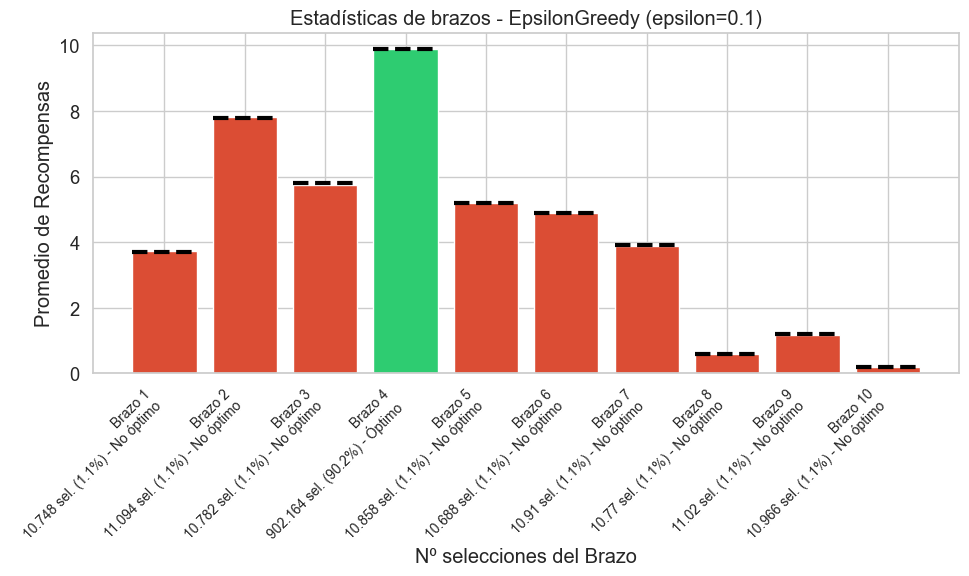

In [17]:
plot_arm_statistics(arm_stats, algorithms, [bandit.get_expected_value(i) for i in range(k)])

##### **3.1 Análisis Histogramas selección de brazos**

Estas tres gráficas muestras los diferentes histográmas de cada algoritmo, mostrándose el número de veces que ha elegido cada algoritmo a cada brazo del bandido, además de mostrar la recompensa promedia y el brazo óptimo final.

La distribución binomial con n=10 equivale a sumar 10 distribuciones de Bernuilli, por lo que cada recompensa del bandido es más informativa que un bandido que sigue una distribución de Bernuilli.

Cada brazo se selecciona una vez al inicio de la ejecución, lo que permite a los algoritmos tener información sobre las distribuciones de los brazos desde el inicio. Se observa como el brazo óptimo tiene una recompensa media de 9.9, seguido del segundo mejor recompensa media de 7.8. Esta diferencia de 2.1 permite que los algoritmos converjan antes.

1. **Histograma ε=0**: Es el primer histograma. El brazo óptimo se ha seleccionado un 99.1% de las ocasiones. Este valor es coherente con inicialización del algoritmo, que corresponde un 1% de los pasos.

3. **Histograma ε=0.01**: Es el segundo histograma. El brazo óptimo se ha seleccionado un 98.2% de las ocasiones. Este valor es coherente con inicialización del algoritmo, que corresponde a un 1% de los pasos, y la tasa de exploración, 1% de los pasos, por lo que el porcentaje de selección del brazo óptimo se estabilizará en torno al 99% una vez el algoritmo converge al brazo óptimo.

3. **Histograma ε=0.1**: Es el tercer histograma. El brazo óptimo se ha seleccionado un 90.2% de las ocasiones, siendo coherente con la inicialización y tasa de exploración del algoritmo.

A continuación, se analizan los boxplots de las estimaciones de recompensas de cada brazo para cada algoritmo.

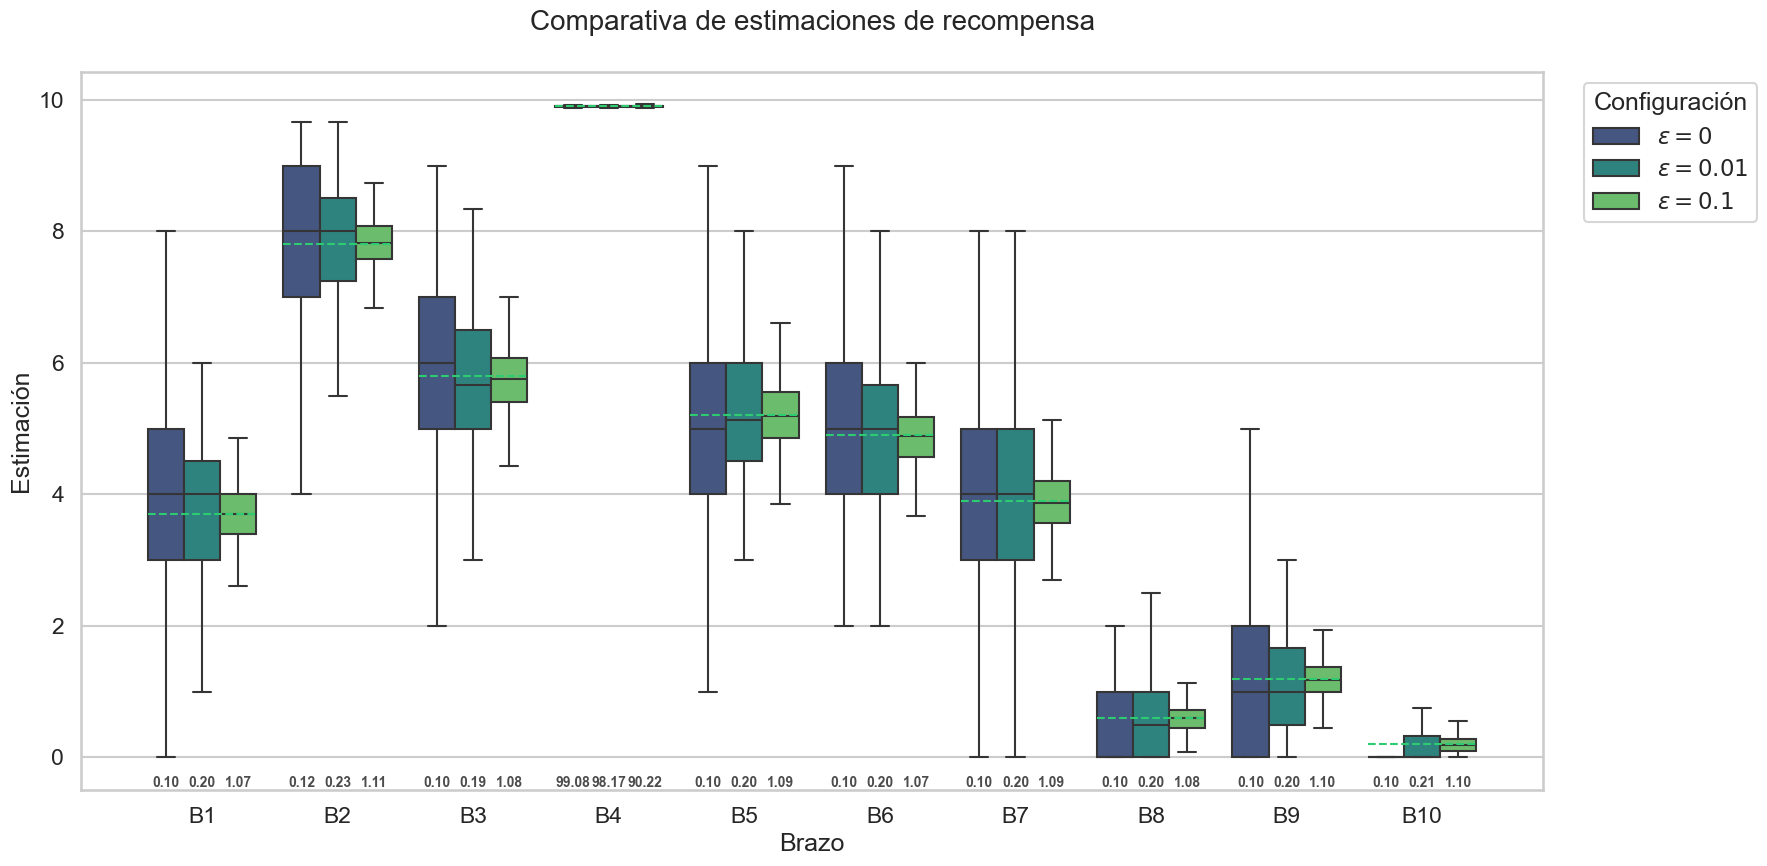

In [18]:
boxplot_estimaciones_brazos(all_runs_data, all_runs_counts, algorithms, [bandit.get_expected_value(i) for i in range(k)])

##### **3.2 Análisis Boxplots de estimaciones de recompensas de cada brazo**

Se presenta un boxplot que muestra las estimaciones finales del valor esperado de cada brazo para cada algoritmo. La media real de la distribución normal de cada brazo se muestra con una **línea verde**, por lo que cuanto más cercano a esta línea y más estrecho sea el boxplot, más precisa será la estimación.

* **Algoritmo 1 (ε-greedy con ε=0)**: Este algoritmo presenta distribuciones más anchas para la mayoría de brazos debido a que se selecciona un menor número de veces cada brazo. El brazo óptimo, al seleccionarse un mayor número de veces, la distribución es más estrecha

* **Algoritmo 2 (ε-greedy con ε=0.01)**: Este algoritmo presenta distribuciones más estrechas que el anterior para la mayoría de brazos no óptimos debido a que se selecciona un mayor número de veces cada brazo (0.2% frente a 0.1%).

* **Algoritmo 3 (ε-greedy con ε=0.1)**: Este algoritmo presenta las distribuciones más estrechas, y ejecuta cada brazo aproximadamente un mínimo de 1.1%.

Como **conclusiones** de esta gráfica, se observa que los brazos seleccionados con menor frecuencian tienen estimaciones más variables, distribuidas alrededor de la media de la distribución de dicho brazo. Esto muestra la relevancia de ε para la estimación de las recompensas. Además, se observa como se obtienen estimaciones más exactas que en el bandido que sigue la distribución de Bernuilli, que da menos información por recompensa.

A continación, se muestra la recompensa promedio que obtiene cada algoritmo a lo largo del tiempo.

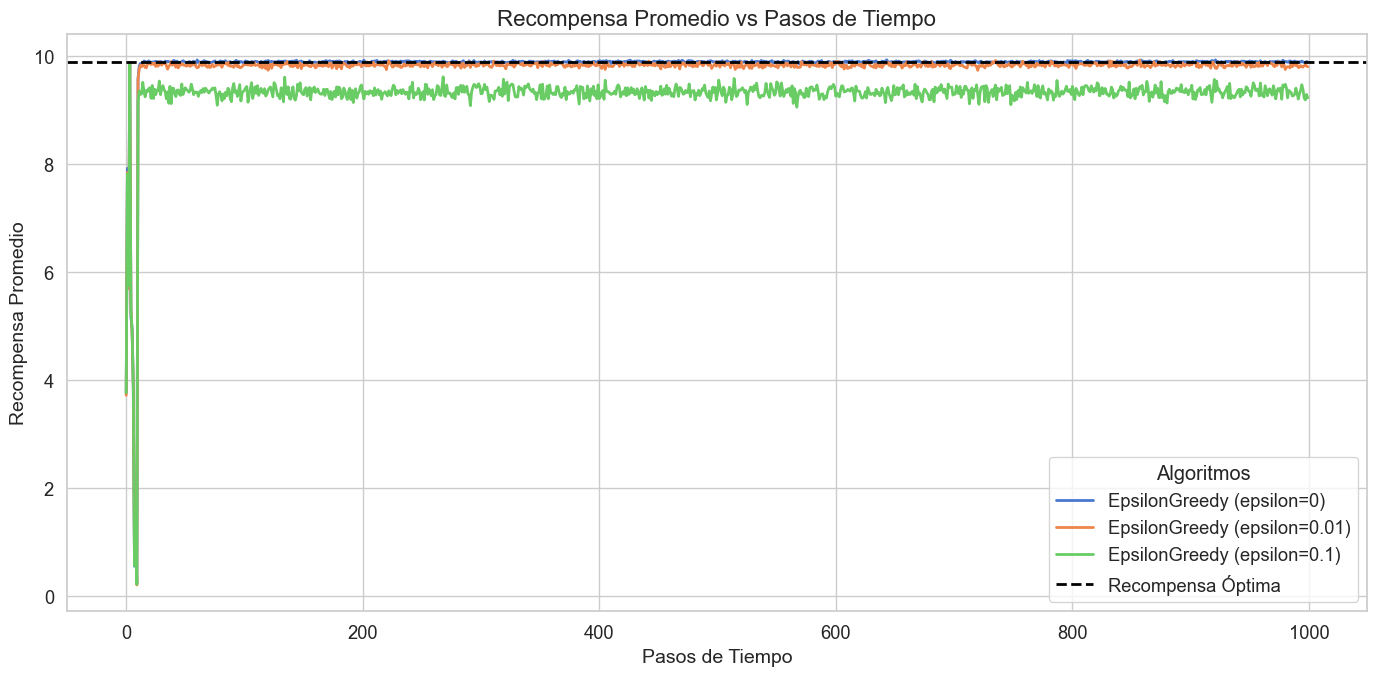

In [19]:
plot_average_rewards(steps, rewards, algorithms, optimal_reward=bandit.get_expected_value(bandit.optimal_arm))

##### **3.3 Análisis Recompensa promedio**

La gráfica muestra la recompensa promedia de los tres algoritmos de **ε-greedy** con distinto valor de **ε** durante los pasos de la ejecución. En el eje **x** se muestra los pasos de tiempo que van desde $0$ hasta $1000$ y en el eje **y** se muestra las recompensas promedio obtenidas en cada paso que van desde $0$ hasta $10$.  La **línea discontinua negra** representa la recompensa del brazo óptimo.

Al inicio el algoritmo tiene una pendiente muy pronunciada por la fase de inicialización del algoritmo, en la que se selecciona cada brazo una vez. Se observa que los algoritmos rápidamente convergen a una recompensa media estable. 

Se ven las siguientes diferencias entre algoritmos:

* **Línea azul (ε-greedy con `ε=0`)**: Tiene una recompensa promedio similar a la del brazo óptimo.

* **Línea naranja (ε-greedy con `ε=0.01`)**: Este algoritmo tiene una recompensa promedio cercana a la obtenida con ε=0, pero ligeramente menor. Esto se debe a su componente exploratoria, seleccionando brazos subóptimos el 1% de las veces.

* **Línea verde (ε-greedy con `ε=0.1`)**: Tiene una recompensa promedio de aproximadamente 9, lo que corresponde con su límite teórico, dado que el 10% de las ocasiones selecciona un brazo aleatoriamente por su componente exploratoria.

A continuación, se muestra el porcentaje de selección del brazo óptimo a lo largo del tiempo

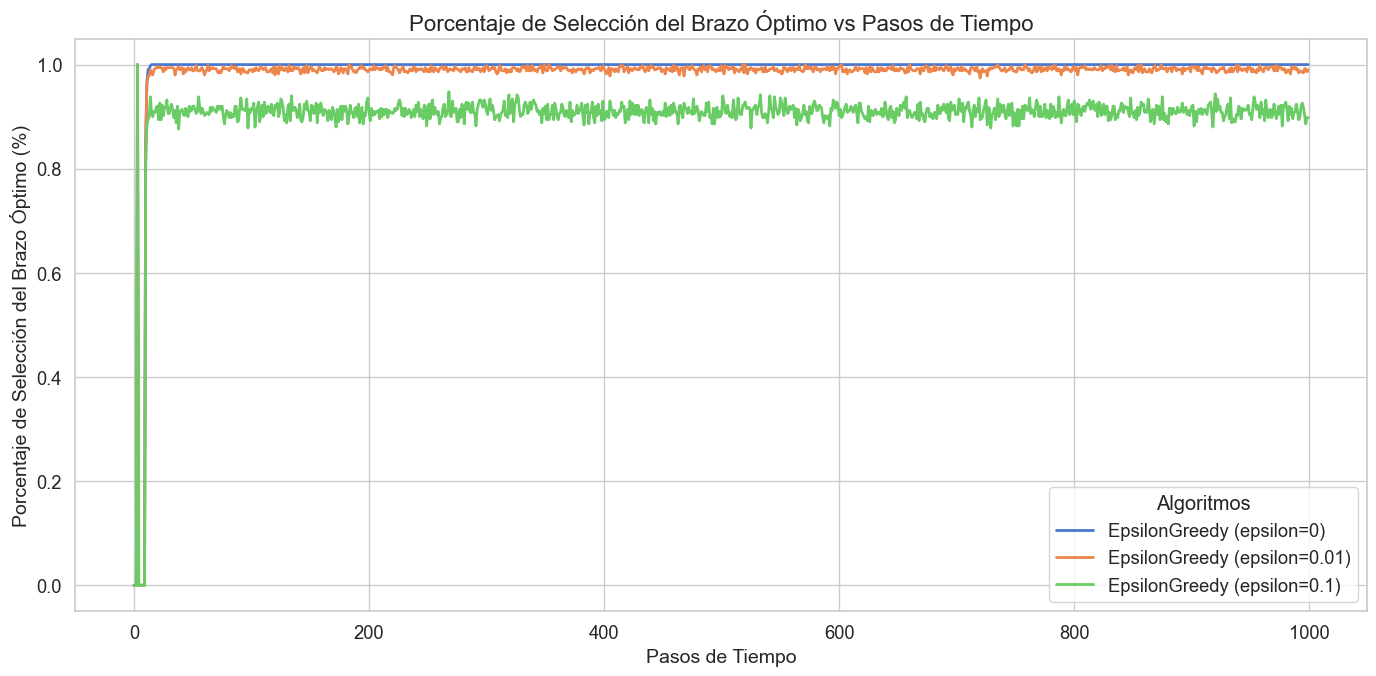

In [20]:
plot_optimal_selections(steps, optimal_selections, algorithms)

##### **3.4 Análisis Porcentaje selección óptimo**

Esta gráfica muestra la **evolución del porcentaje de selección del brazo óptimo** durante la ejecución. En el eje **x** aparece el número de pasos de tiempo que realizar cada algoritmo, de $0$ a $1000$, y en el eje **y** aparece el porcentaje de selección del brazo óptimo, de $0$ a $1$.

Al igual que en la gráfica anterior, al inicio el algoritmo tiene una pendiente muy pronunciada por la fase de inicialización del algoritmo, y se observa que los algoritmos rápidamente convergen a un porcentaje de selección estable.

* **Línea azul (ε-greedy con `ε=0`)**: Selecciona el brazo óptimo en un valor muy cercano al 100% de las ocasiones.

* **Línea naranja (ε-greedy con `ε=0.01`)**: Selecciona un gran porcentaje de veces el brazo óptimo, pero con un porcentaje ligeramente menor al ε=0, debido a su componente exploratoria.

* **Línea verde (ε-greedy con `ε=0.1`)**: Selecciona el brazo óptimo alrededor del 90% de las veces, lo que corresponde con su límite teórico, dado que el 10% de las ocasiones selecciona un brazo aleatoriamente por su componente exploratoria.

A continuación, se muestra el regret acumulado durante los pasos del tiempo. 

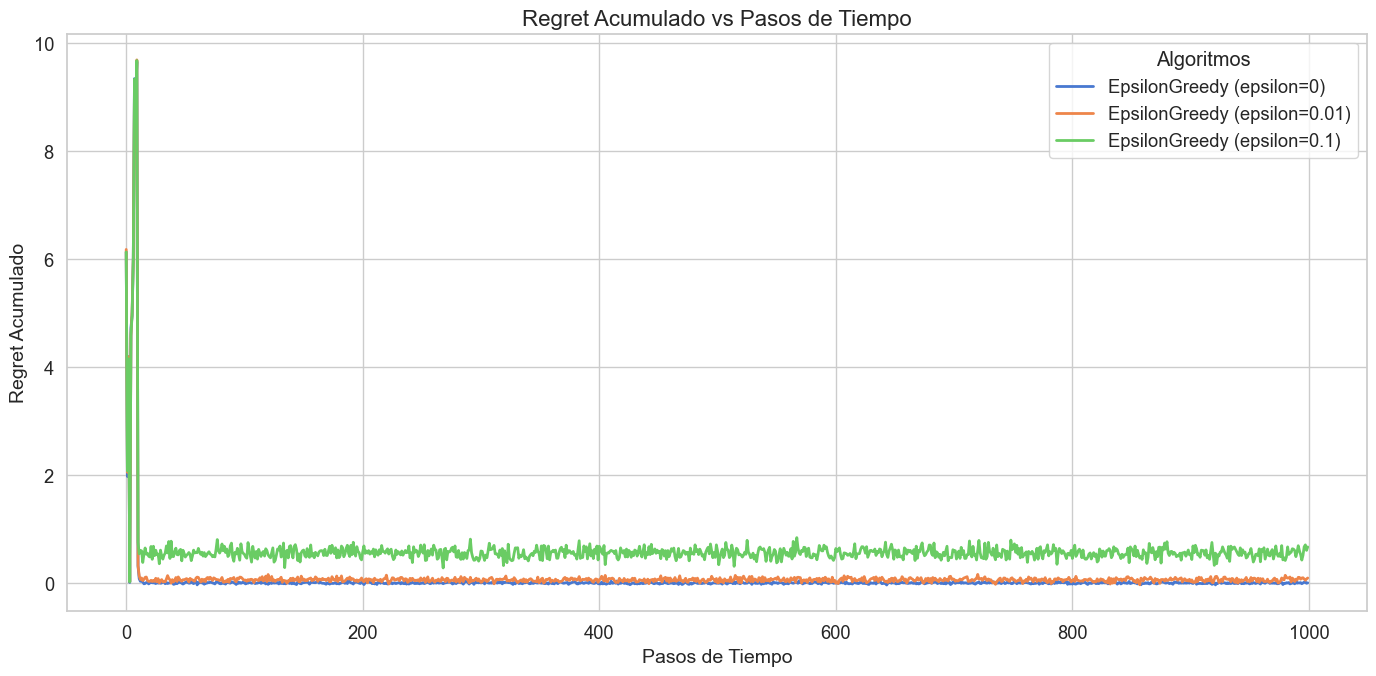

In [21]:
plot_regret(steps, regrets, algorithms)

##### **3.5 Análisis arrepentimiento acumulado**

Esta gráfica muestra la **evolución del arrepentimiento acumulado** de cada algoritmo. En el eje **x** aparece el número de pasos de tiempo que realizar cada algoritmo, de $0$ a $1000$, y en el eje **y** aparece el arrepentimiento acumulado, desde $0$ hasta $10$. La diferencia de las dos primeras gráficas es que ahora se busca disminuir el valor de arrepentimiento acumulado.

* **Línea azul (ε-greedy con `ε=0`)**: El regret es cercano a 0 debido a que se selecciona el brazo óptimo aproximadamente el 100% de las veces.

* **Línea naranja (ε-greedy con `ε=0.01`)**: El regret es cercano a 0, pero mayor que con ε=0, lo que corresponde con su selección ligeramente menor del brazo óptimo.

* **Línea verde (ε-greedy con `ε=0.1`)**: El regret es ligeramente menor a 1. Esto es consistente con la componente exploratoria del algoritmo.

## **Conclusiones**

En este estudio hemos analizado el rendimiento del algoritmo de **ε-greedy** en el contexto del **problema del bandido de k-brazos**, un problema básico dentro del aprendizaje por refuerzo. Hemos comparado el rendimiento de dicho algoritmo utilizando diferentes valores del parámetro ``ε``, y diferentes tipos de distribuciones de probabilidad para la recompensa dada por el bandido. Las conclusiones a las que hemos llegado son las siguientes:

1. **Importancia de la distribución si ε=0**
    Se han comparado las distribuciones **normal**, **bernoulli**, y **binomial**. Las distribuciones que mayor información dan por cada selección, permiten al algoritmo obtener mejor estimación de la recompensa de cada brazo en la fase inicial, en la que se selecciona cada brazo una vez, lo que permite que el algoritmo se seleccione un mayor número de veces. Esto influye en el porcentaje de selección del brazo óptimo, y por lo tanto en la recompensa media obtenida.

    Por lo tanto, cuanta más información por recompensa se obtiene, mejores resultados da.

2. **Importancia de los brazos con recompensa media cercana al óptimo**
    Los brazos con recompensa media cercana al valor óptimo (10-20% de diferencia) tienen un número elevado de selecciones, debido a que el algoritmo le cuesta más distinguir entre estos y el brazo óptimo. Cuantos más brazos con medias cercanas, más confusiones tendrá el algoritmo, y menor porcentaje tendrá el brazo óptimo.

    Para valores de ε>0, esto implica una convergencia más lenta. Para ε=0, esto implica una recompensa menor, dado que no explora. En estas ocasiones, ε=0.1 converge más rápidamente que ε=0.01.

3. **Importancia de la tasa de exploración (``ε``) cuando se converge al brazo óptimo**
    Cuando los brazos con ε>0 convergen al brazo óptimo, el algoritmo con ε=0.1 se ve limitado dado que un 10% de las ocasiones explora de forma obligatoria. Sin embargo, el algoritmo con ε=0.01 se ve limitado en un menor porcentaje (un 1%), por lo que cuando converge obtiene mayor recompensa media.

4. **Parámetro ``ε``: Exploración frente Explotación**
    Dados los anteriores puntos, el mejor valor de ε es 0.1 en las ocasiones donde se obtiene menor información por recompensa, hay brazos con recompensas cercanas al óptimo, y se ejecuta el algoritmo un menor número de pasos de tiempo. Sin embargo, en el caso de ejecutarse un mayor número de pasos del tiempo, es mejor el algoritmo con ε 0.01 porque, al converger, no se ve tan limitado por su tasa exploratoria.

    No se recomienda el parámetro ε=0 por su falta de componente exploratoria, incluso en número de pasos bajo es mejor escoger un algoritmo con ε>0.

5. **Relación selección de brazos frente estimación**
    
    Cuanto mayor número de ocasiones se selecciona un brazo, mejores estimaciones se obtienen, y más estrecha es la distribución de estimaciones.